# Heart Murmur Classification

Our dataset is from circoDigiscope, we aim to run a binary murmur grading
link to dataset: can be downloaded if you set up login however we download first then run due to the site having really slow access rates

https://physionet.org/content/circor-heart-sound/1.0.3/

This notebook is divided into two parts.

Part 1: here we run a progressive architecture study, comparing Vanilla LSTM, BiLSTM, CNN-BiLSTM, BiLSTM with attention, and a stacked BiLSTM with skip connections. Each architecture is tuned over the same hyperparameter grid using 3-fold cross-validation on the training set, and the winner is selected by validation macro F1.

Part 2 takes the winning CNN-BiLSTM architecture and applies the following upgrades, dilated CNN, per-layer skip connections, hybrid pooling, and denser frame extraction. Then runs a hyperparamter config to reach best config

link to notebook in collab: https://drive.google.com/file/d/1a4cEC38VZZzcdg9UqXiEFkcfrFbn-PXX/view?usp=sharing

# Part 1: Our Architecture Study

Sections 1 to 6 progressively build from Vanilla LSTM to CNN-BiLSTM variants. Each architecture is tuned via 3-fold CV grid search. The winning architecture proceeds to Part 2.

## Install and Imports

In [ ]:
!pip install librosa soundfile -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## Data Loading

Reads the CirCor DigiScope dataset from Google Drive.

Features are 39-dimensional: 13 MFCCs plus first and second order deltas, computed per cardiac cycle.
Cycles are segmented using S1 events based on the `.tsv` annotation files. Labels are binary: Soft (grades I-II) and Loud (grades III and above).
The dataset is split patient-wise 70/15/15 into train, validation, and test sets, stratified by class.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import librosa
from collections import Counter
from sklearn.model_selection import train_test_split

# Locate dataset root
SEARCH_ROOT = Path('/content/drive/MyDrive/st311_code_plus_data/the-circor-digiscope-phonocardiogram-dataset-1.0.3/the-circor-data')
csv_candidates = list(SEARCH_ROOT.rglob('training_data.csv'))
assert len(csv_candidates) > 0, f'training_data.csv not found under {SEARCH_ROOT}'

csv_path  = csv_candidates[0]
DATA_DIR  = csv_path.parent
TRAIN_DIR = DATA_DIR / 'training_data'

wav_files = list(TRAIN_DIR.glob('*.wav'))
print(f'CSV found     : {csv_path}')
print(f'Training dir  : {TRAIN_DIR}')
print(f'WAV files     : {len(wav_files)}')
assert len(wav_files) > 0, f'No WAV files found in {TRAIN_DIR}'

# Load CSV and map murmur grading to Soft / Loud
df = pd.read_csv(str(csv_path))
df = df[df['Murmur'] == 'Present'].copy()

GRADE_MAP = {
    'I/VI':   'Soft', 'II/VI':  'Soft',
    'III/VI': 'Loud', 'IV/VI':  'Loud',
    'V/VI':   'Loud', 'VI/VI':  'Loud',
}
df['recording_class'] = df['Systolic murmur grading'].map(GRADE_MAP)
df = df[df['recording_class'].notna()].copy()

print(f'Patients after filtering : {len(df)}')
print(df['recording_class'].value_counts().to_string())

# Build per-recording rows
rows = []
for _, row in df.iterrows():
    pid  = str(row['Patient ID'])
    locs = str(row['Recording locations:']).split('+')
    for loc in locs:
        loc = loc.strip()
        wav = TRAIN_DIR / f'{pid}_{loc}.wav'
        tsv = TRAIN_DIR / f'{pid}_{loc}.tsv'
        if wav.exists() and tsv.exists():
            rows.append({
                'patient_id':      pid,
                'location':        loc,
                'wav_path':        wav,
                'tsv_path':        tsv,
                'recording_class': row['recording_class'],
            })

rec_df = pd.DataFrame(rows)
print(f'\nRecordings found : {len(rec_df)}')
print(rec_df['recording_class'].value_counts().to_string())

# Extract MFCC cycles
# TSV labels: 0=unknown, 1=S1, 2=S2, 3=systole, 4=diastole
# One cardiac cycle = S1 to next S1
# hop_length=128 at sr=2000 gives roughly 15 frames per 0.6s cycle
TARGET_SR  = 2000
N_MFCC     = 13
HOP_LENGTH = 128
N_FFT      = 256

def extract_cycles_mfcc(wav_path, tsv_path,
                        target_sr=TARGET_SR, n_mfcc=N_MFCC,
                        min_dur=0.2, max_dur=2.0):
    """
    Extract per-cycle MFCC features from a single recording.

    Parameters
    ----------
    wav_path : Path
        Path to the .wav file.
    tsv_path : Path
        Path to the .tsv annotation file.
    target_sr : int
        Sample rate to resample audio to.
    n_mfcc : int
        Number of MFCC coefficients.
    min_dur : float
        Minimum cycle duration in seconds.
    max_dur : float
        Maximum cycle duration in seconds.

    Returns
    -------
    cycles : list of np.ndarray, each of shape (T, 39)
        List of feature matrices, one per valid cardiac cycle.
    """
    audio, _ = librosa.load(str(wav_path), sr=target_sr)
    seg = pd.read_csv(str(tsv_path), sep='\t', header=None,
                      names=['start', 'end', 'label'])
    seg['label'] = seg['label'].astype(int)
    s1 = seg[seg['label'] == 1].reset_index(drop=True)
    cycles = []
    for i in range(len(s1) - 1):
        start_sec = float(s1.loc[i,   'start'])
        end_sec   = float(s1.loc[i+1, 'start'])
        dur = end_sec - start_sec
        if not (min_dur <= dur <= max_dur):
            continue
        cycle = audio[int(start_sec * target_sr):int(end_sec * target_sr)]
        if len(cycle) < N_FFT:
            continue
        mfcc   = librosa.feature.mfcc(y=cycle, sr=target_sr, n_mfcc=n_mfcc,
                                       hop_length=HOP_LENGTH, n_fft=N_FFT)
        delta  = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)
        feat   = np.vstack([mfcc, delta, delta2])  # (39, T)
        cycles.append(feat.T)                       # (T, 39)
    return cycles

all_cycles, all_labels, all_meta = [], [], []
skipped = 0
errors  = []
for _, row in rec_df.iterrows():
    try:
        cycles = extract_cycles_mfcc(row['wav_path'], row['tsv_path'])
        if len(cycles) == 0:
            skipped += 1
            continue
    except Exception as e:
        skipped += 1
        errors.append((str(row['wav_path'].name), str(e)))
        continue
    for c in cycles:
        all_cycles.append(c)
        all_labels.append(row['recording_class'])
        all_meta.append((row['patient_id'], row['location']))

print(f'\nCycles extracted : {len(all_cycles)}  |  skipped recordings: {skipped}')
print(Counter(all_labels))
if errors:
    print(f'\nFirst 3 errors:')
    for name, err in errors[:3]:
        print(f'  {name}: {err}')
assert len(all_cycles) > 0, 'No cycles extracted — check errors above.'

# Patient-wise train / val / test split (70 / 15 / 15)
label_arr = np.array(all_labels)
meta_df   = pd.DataFrame(all_meta, columns=['patient_id', 'location'])
meta_df['label']     = label_arr
meta_df['cycle_idx'] = np.arange(len(all_cycles))

patient_class = (
    meta_df.groupby('patient_id')['label']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'label': 'dominant_class'})
)

train_pids, temp_pids = train_test_split(
    patient_class['patient_id'],
    test_size=0.30, stratify=patient_class['dominant_class'], random_state=42)
temp_class = patient_class[patient_class['patient_id'].isin(temp_pids)]
val_pids, test_pids = train_test_split(
    temp_class['patient_id'],
    test_size=0.50, stratify=temp_class['dominant_class'], random_state=42)

def get_split(pids):
    idx = meta_df[meta_df['patient_id'].isin(pids)]['cycle_idx'].values
    return [all_cycles[i] for i in idx], np.array([all_labels[i] for i in idx])

X_train, y_train = get_split(train_pids)
X_val,   y_val   = get_split(val_pids)
X_test,  y_test  = get_split(test_pids)

print(f'\nSplit complete.')
print(f'  Train : {len(X_train)} cycles  ({Counter(y_train)})')
print(f'  Val   : {len(X_val)}   cycles  ({Counter(y_val)})')
print(f'  Test  : {len(X_test)}  cycles  ({Counter(y_test)})')
print(f'  Sample cycle shape: {X_train[0].shape}')

Mounted at /content/drive
CSV found     : /content/drive/MyDrive/st311_code_plus_data/the-circor-digiscope-phonocardiogram-dataset-1.0.3/the-circor-data/training_data.csv
Training dir  : /content/drive/MyDrive/st311_code_plus_data/the-circor-digiscope-phonocardiogram-dataset-1.0.3/the-circor-data/training_data
WAV files     : 3163
Patients after filtering : 178
recording_class
Soft    132
Loud     46

Recordings found : 602
recording_class
Soft    417
Loud    185

Cycles extracted : 6235  |  skipped recordings: 281
Counter({'Soft': 3724, 'Loud': 2511})

First 3 errors:
  14241_AV.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=8
  14241_PV.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=8
  14241_TV.wav: when mode='interp', width=9 cannot exceed data.shape[axis]=5

Split complete.
  Train : 4333 cycles  (Counter({np.str_('Soft'): 2516, np.str_('Loud'): 1817}))
  Val   : 803   cycles  (Counter({np.str_('Soft'): 488, np.str_('Loud'): 315}))
  Test  : 1099 

## Shared Infrastructure

Dataset class, collate function, DataLoaders, and the generic training loop. All models in Stages 1 through 3 share this infrastructure this ensures fairness in determining best base architecture

In [ ]:
le = LabelEncoder()
le.fit(['Soft', 'Loud'])

y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Train class dist:', Counter(y_train))
print('Val   class dist:', Counter(y_val))
print('Test  class dist:', Counter(y_test))

INPUT_SIZE = X_train[0].shape[1]   # 39
N_CLASSES  = 2
print(f'\nInput feature size: {INPUT_SIZE}')

Label mapping: {np.str_('Loud'): np.int64(0), np.str_('Soft'): np.int64(1)}
Train class dist: Counter({np.str_('Soft'): 2516, np.str_('Loud'): 1817})
Val   class dist: Counter({np.str_('Soft'): 488, np.str_('Loud'): 315})
Test  class dist: Counter({np.str_('Soft'): 720, np.str_('Loud'): 379})

Input feature size: 39


In [ ]:
class CycleDataset(Dataset):
    """
    Dataset wrapping variable-length cardiac cycle sequences.

    Parameters
    ----------
    X : list of np.ndarray, each of shape (T_i, 39)
    y : np.ndarray of int, shape (N,)
    """
    def __init__(self, X, y):
        self.X = [torch.tensor(x, dtype=torch.float32) for x in X]
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def collate_fn(batch):
    """
    Pads variable-length sequences in a batch to the same length.

    Returns
    -------
    padded : (B, T_max, 39)
    lengths : (B,)
    labels  : (B,)
    """
    seqs, labels = zip(*batch)
    lengths = torch.tensor([s.shape[0] for s in seqs])
    padded  = pad_sequence(seqs, batch_first=True)
    return padded, lengths, torch.stack(labels)


def make_loader(X, y_enc, batch_size=64, balanced=False, shuffle=False):
    """
    Build a DataLoader, optionally with weighted sampling for class balance.

    Parameters
    ----------
    X       : list of arrays
    y_enc   : np.ndarray of encoded labels
    balanced: if True, use WeightedRandomSampler so each class is equally likely
    """
    ds = CycleDataset(X, y_enc)
    if balanced:
        counts = np.bincount(y_enc)
        w = torch.tensor([1.0 / counts[yi] for yi in y_enc])
        sampler = torch.utils.data.WeightedRandomSampler(w, len(w), replacement=True)
        return DataLoader(ds, batch_size=batch_size, sampler=sampler, collate_fn=collate_fn)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)


BATCH_SIZE = 64

train_loader = make_loader(X_train, y_train_enc, BATCH_SIZE, balanced=True)
val_loader   = make_loader(X_val,   y_val_enc,   BATCH_SIZE)
test_loader  = make_loader(X_test,  y_test_enc,  BATCH_SIZE)

print(f'Loaders ready — batches per epoch: {len(train_loader)}')

Loaders ready — batches per epoch: 68


In [ ]:
cw = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
print('Class weights:', dict(zip(le.classes_, cw.round(3))))

Class weights: {np.str_('Loud'): np.float64(1.192), np.str_('Soft'): np.float64(0.861)}


In [ ]:
def train_model(model, epochs=80, lr=5e-4, weight_decay=1e-3,
                patience=15, grad_clip=1.0, label='model',
                train_ld=None, val_ld=None):
    """
    Train a model with early stopping, returning the best validation F1.

    Parameters
    ----------
    model      : nn.Module
    epochs     : maximum number of training epochs
    lr         : learning rate for Adam
    weight_decay: L2 regularisation coefficient
    patience   : epochs without improvement before early stopping
    grad_clip  : gradient clipping threshold
    label      : string label used in progress prints
    train_ld   : training DataLoader (defaults to train_loader)
    val_ld     : validation DataLoader (defaults to val_loader)

    Returns
    -------
    best_f1  : float, best validation macro F1 achieved
    history  : dict with keys train_f1, val_f1, train_loss, val_loss
    """
    train_ld = train_ld or train_loader
    val_ld   = val_ld   or val_loader

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=7, factor=0.5, min_lr=1e-6)

    best_f1, best_state, patience_ctr = 0.0, None, 0
    history = {'train_f1': [], 'val_f1': [], 'train_loss': [], 'val_loss': []}

    for ep in range(1, epochs + 1):
        # Training pass
        model.train()
        tp, tt, tl = [], [], []
        for x, lengths, y in train_ld:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x, lengths)
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            tl.append(loss.item())
            tp.extend(logits.argmax(1).detach().cpu().numpy())
            tt.extend(y.cpu().numpy())

        # Validation pass
        model.eval()
        vp, vt, vl = [], [], []
        with torch.no_grad():
            for x, lengths, y in val_ld:
                x, lengths, y = x.to(device), lengths.to(device), y.to(device)
                logits = model(x, lengths)
                vl.append(criterion(logits, y).item())
                vp.extend(logits.argmax(1).cpu().numpy())
                vt.extend(y.cpu().numpy())

        tf1 = f1_score(tt, tp, average='macro', zero_division=0)
        vf1 = f1_score(vt, vp, average='macro', zero_division=0)
        history['train_f1'].append(tf1)
        history['val_f1'].append(vf1)
        history['train_loss'].append(np.mean(tl))
        history['val_loss'].append(np.mean(vl))
        scheduler.step(np.mean(vl))

        if vf1 > best_f1:
            best_f1      = vf1
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  [{label}] Early stop @ ep {ep}  best val F1={best_f1:.4f}')
                break

        if ep % 10 == 0:
            print(f'  [{label}] Ep {ep:03d} | '
                  f'Train F1: {tf1:.3f}  Val F1: {vf1:.3f}  Best: {best_f1:.3f}')

    model.load_state_dict(best_state)
    return best_f1, history


def eval_on_test(model, label='model'):
    """
    Evaluate a model on the held-out test set and print a classification report.

    Parameters
    ----------
    model : nn.Module with best weights already loaded
    label : string label for the printed header

    Returns
    -------
    macro_f1 : float
    """
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, lengths, y in test_loader:
            x, lengths = x.to(device), lengths.to(device)
            logits = model(x, lengths)
            preds.extend(logits.argmax(1).cpu().numpy())
            targets.extend(y.numpy())
    macro_f1 = f1_score(targets, preds, average='macro', zero_division=0)
    print(f'\n{label} — Test Set')
    print(classification_report(targets, preds, target_names=le.classes_))
    cm = confusion_matrix(targets, preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{label} — Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return macro_f1


def plot_history(history, title):
    """
    Plot training and validation loss and macro F1 over epochs.

    Parameters
    ----------
    history : dict with keys train_loss, val_loss, train_f1, val_f1
    title   : string used as the plot title prefix
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history['train_f1']) + 1)
    ax1.plot(epochs, history['train_loss'], label='Train')
    ax1.plot(epochs, history['val_loss'],   label='Val')
    ax1.set_title(f'{title} — Loss')
    ax1.legend()
    ax2.plot(epochs, history['train_f1'], label='Train')
    ax2.plot(epochs, history['val_f1'],   label='Val')
    ax2.set_title(f'{title} — Macro F1')
    ax2.legend()
    plt.tight_layout()
    plt.show()

print('Shared infrastructure ready.')

Shared infrastructure ready.


In [ ]:
def grid_search(build_model_fn, param_grid, label='model',
                epochs=40, patience=12, n_folds=2):
    """
    2-fold cross-validated grid search over the training set.

    Parameters
    ----------
    build_model_fn : callable(**params) -> nn.Module
    param_grid     : list of dicts, e.g. [{'lr': 5e-4, 'dropout': 0.3}, ...]
    label          : string label for progress output
    epochs         : maximum epochs per fold
    patience       : early stopping patience per fold
    n_folds        : number of CV folds (default 2 for speed)

    Returns
    -------
    best_params : dict with the hyperparameter configuration that achieved
                  the highest mean validation F1 across folds
    """
    from sklearn.model_selection import StratifiedKFold
    X_arr = np.arange(len(X_train))

    print(f'Grid search for {label} — {len(param_grid)} configs x {n_folds} folds')
    results = []

    for params in param_grid:
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
        fold_f1s = []
        for fold, (tr_idx, vl_idx) in enumerate(skf.split(X_arr, y_train_enc)):
            X_tr = [X_train[i] for i in tr_idx]; y_tr = y_train_enc[tr_idx]
            X_vl = [X_train[i] for i in vl_idx]; y_vl = y_train_enc[vl_idx]

            cw_f = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
            global class_weights
            class_weights = torch.tensor(cw_f, dtype=torch.float32).to(device)

            tr_ld = make_loader(X_tr, y_tr, batch_size=BATCH_SIZE, balanced=True)
            vl_ld = make_loader(X_vl, y_vl, batch_size=BATCH_SIZE)

            m = build_model_fn(**params).to(device)
            best_f1, _ = train_model(
                m, epochs=epochs, lr=params.get('lr', 5e-4),
                weight_decay=params.get('weight_decay', 1e-3),
                patience=patience, label=f'{label} cfg={params} fold={fold+1}',
                train_ld=tr_ld, val_ld=vl_ld)
            fold_f1s.append(best_f1)

        mean_f1 = np.mean(fold_f1s)
        print(f'  params={params}  ->  mean F1={mean_f1:.4f} +/- {np.std(fold_f1s):.4f}')
        results.append((mean_f1, params))

    # Restore full training class weights
    cw_full = compute_class_weight('balanced', classes=np.unique(y_train_enc), y=y_train_enc)
    class_weights = torch.tensor(cw_full, dtype=torch.float32).to(device)

    best_mean, best_params = max(results, key=lambda x: x[0])
    print(f'\nBest config: {best_params}  (F1={best_mean:.4f})')
    return best_params

print('Grid-search helper ready.')

Grid-search helper ready.


In [ ]:
# Shared hyperparameter grid used by all models for fair comparison.
# lr in {1e-4, 5e-4, 1e-3} x dropout in {0.3, 0.4, 0.5} = 8 configurations.
# CNN-BiLSTM additionally searches cnn_channels in {32, 64} = 16 configurations.

SHARED_GRID = [
    {'lr': 1e-4, 'dropout': 0.3},
    {'lr': 5e-4, 'dropout': 0.3},
    {'lr': 1e-3, 'dropout': 0.3},
    {'lr': 1e-4, 'dropout': 0.4},
    {'lr': 5e-4, 'dropout': 0.4},
    {'lr': 1e-3, 'dropout': 0.4},
    {'lr': 5e-4, 'dropout': 0.5},
    {'lr': 1e-3, 'dropout': 0.5},
]

CNN_GRID = [
    {'lr': lr, 'dropout': do, 'cnn_channels': ch}
    for lr in [1e-4, 5e-4, 1e-3]
    for do in [0.3, 0.4, 0.5]
    for ch in [32, 64]
]

print(f'Shared grid: {len(SHARED_GRID)} configs')
print(f'CNN grid   : {len(CNN_GRID)} configs')

Shared grid: 8 configs
CNN grid   : 18 configs


## Stage 1 : Vanilla LSTM (Baseline)

Unidirectional LSTM with masked mean-pool over valid timesteps. This is the baseline our baseline determines whether adding bidirectionalit even helps
Tuning grid: lr in {1e-4, 5e-4, 1e-3}, dropout in {0.3, 0.4}.

In [ ]:
class VanillaLSTM(nn.Module):
    """
    Baseline unidirectional LSTM with masked mean-pool.

    Parameters
    ----------
    in_size   : input feature dimension (39)
    hidden    : LSTM hidden size
    layers    : number of stacked LSTM layers
    dropout   : dropout probability applied between LSTM layers and before head
    n_classes : number of output classes

    Example
    -------
    >>> model = VanillaLSTM()
    >>> x = torch.randn(32, 20, 39)
    >>> lengths = torch.randint(10, 20, (32,))
    >>> model(x, lengths).shape
    torch.Size([32, 2])
    """
    def __init__(self, in_size=INPUT_SIZE, hidden=128, layers=2,
                 dropout=0.3, n_classes=N_CLASSES, **kwargs):
        super().__init__()
        self.lstm = nn.LSTM(in_size, hidden, layers, batch_first=True,
                            bidirectional=False,
                            dropout=dropout if layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )

    def forward(self, x, lengths):
        # x: (B, T, 39)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)
        # out: (B, T, hidden)

        # Masked mean-pool over valid timesteps
        mask   = (torch.arange(out.size(1), device=out.device)[None, :]
                  < lengths.to(out.device)[:, None]).float()
        pooled = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
        # pooled: (B, hidden)
        return self.head(self.drop(self.norm(pooled)))
        # out: (B, n_classes)


print('VanillaLSTM defined.')
print(f'  Params: {sum(p.numel() for p in VanillaLSTM().parameters()):,}')

VanillaLSTM defined.
  Params: 227,266


In [ ]:
lstm_best_params = grid_search(
    build_model_fn=VanillaLSTM,
    param_grid=SHARED_GRID,
    label='VanillaLSTM'
)

Grid search for VanillaLSTM — 8 configs x 2 folds
  [VanillaLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 010 | Train F1: 0.817  Val F1: 0.810  Best: 0.814
  [VanillaLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 020 | Train F1: 0.857  Val F1: 0.847  Best: 0.848
  [VanillaLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 030 | Train F1: 0.878  Val F1: 0.869  Best: 0.869
  [VanillaLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 040 | Train F1: 0.900  Val F1: 0.875  Best: 0.884
  [VanillaLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 010 | Train F1: 0.820  Val F1: 0.805  Best: 0.811
  [VanillaLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 020 | Train F1: 0.857  Val F1: 0.833  Best: 0.845
  [VanillaLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 030 | Train F1: 0.869  Val F1: 0.852  Best: 0.858
  [VanillaLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 040 | Train F1: 0.905  Val F1: 0.860  Best: 0.861
  params={'lr': 0.0001, 'dropout': 0.3}  ->  mean F1=0.8724 +/

Training best VanillaLSTM on full training set...
  [VanillaLSTM] Ep 010 | Train F1: 0.890  Val F1: 0.714  Best: 0.736
  [VanillaLSTM] Early stop @ ep 16  best val F1=0.7359


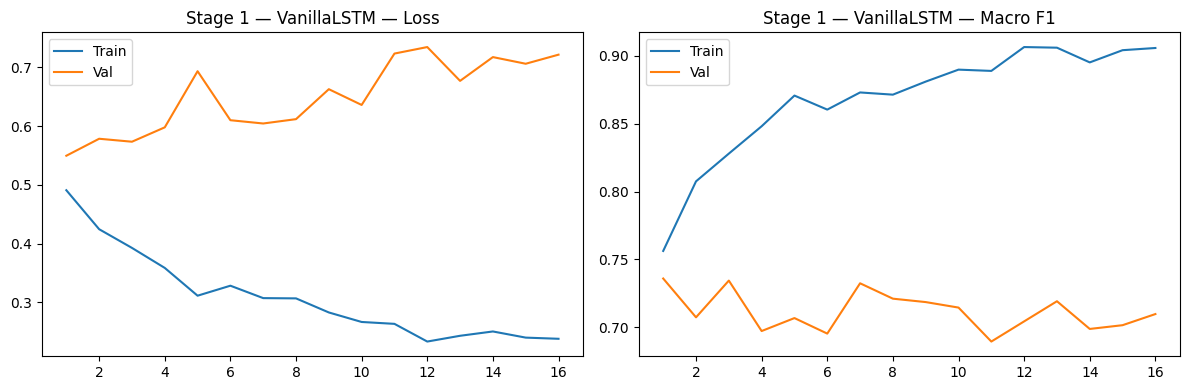


Stage 1 best val F1: 0.7359


In [ ]:
print('Training best VanillaLSTM on full training set...')
lstm_model = VanillaLSTM(**lstm_best_params).to(device)
lstm_best_f1, lstm_history = train_model(
    lstm_model, epochs=40, lr=lstm_best_params['lr'],
    patience=15, label='VanillaLSTM')

plot_history(lstm_history, 'Stage 1 — VanillaLSTM')
print(f'\nStage 1 best val F1: {lstm_best_f1:.4f}')

## Stage 2: The BiLSTM

Architecture is identical to stage 1 exceot for the fact that bidirectionality is added, everything else like the hidden size stays the same; the output doubles to 2 x hidden because of the two directions.

hope to see some expected gain come from the forward and backward context this should appear to help with the temporal structure of cardiac cycles.

In [ ]:
class BiLSTM(nn.Module):
    """
    Bidirectional LSTM — same as VanillaLSTM but with bidirectional=True.

    Parameters
    ----------
    in_size   : input feature dimension (39)
    hidden    : LSTM hidden size per direction (output is hidden * 2)
    layers    : number of stacked BiLSTM layers
    dropout   : dropout probability
    n_classes : number of output classes

    Example
    -------
    >>> model = BiLSTM()
    >>> x = torch.randn(32, 20, 39)
    >>> lengths = torch.randint(10, 20, (32,))
    >>> model(x, lengths).shape
    torch.Size([32, 2])
    """
    def __init__(self, in_size=INPUT_SIZE, hidden=128, layers=2,
                 dropout=0.3, n_classes=N_CLASSES, **kwargs):
        super().__init__()
        self.lstm = nn.LSTM(in_size, hidden, layers, batch_first=True,
                            bidirectional=True,
                            dropout=dropout if layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden * 2)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )

    def forward(self, x, lengths):
        # x: (B, T, 39)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)
        # out: (B, T, hidden * 2)

        # Masked mean-pool over valid timesteps
        mask   = (torch.arange(out.size(1), device=out.device)[None, :]
                  < lengths.to(out.device)[:, None]).float()
        pooled = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
        # pooled: (B, hidden * 2)
        return self.head(self.drop(self.norm(pooled)))
        # out: (B, n_classes)


print('BiLSTM defined.')
print(f'  Params: {sum(p.numel() for p in BiLSTM().parameters()):,}')

BiLSTM defined.
  Params: 585,410


In [ ]:
bilstm_best_params = grid_search(
    build_model_fn=BiLSTM,
    param_grid=SHARED_GRID,
    label='BiLSTM'
)

Grid search for BiLSTM — 8 configs x 2 folds
  [BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 010 | Train F1: 0.833  Val F1: 0.836  Best: 0.836
  [BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 020 | Train F1: 0.873  Val F1: 0.846  Best: 0.851
  [BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 030 | Train F1: 0.900  Val F1: 0.882  Best: 0.882
  [BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 040 | Train F1: 0.916  Val F1: 0.887  Best: 0.891
  [BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 010 | Train F1: 0.832  Val F1: 0.847  Best: 0.847
  [BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 020 | Train F1: 0.881  Val F1: 0.830  Best: 0.864
  [BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 030 | Train F1: 0.899  Val F1: 0.876  Best: 0.876
  [BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 040 | Train F1: 0.924  Val F1: 0.876  Best: 0.883
  params={'lr': 0.0001, 'dropout': 0.3}  ->  mean F1=0.8872 +/- 0.0039
  [BiLSTM cfg={'lr': 0.0005, 'dropou

Training best BiLSTM on full training set...
  [BiLSTM] Ep 010 | Train F1: 0.870  Val F1: 0.745  Best: 0.769
  [BiLSTM] Early stop @ ep 18  best val F1=0.7690


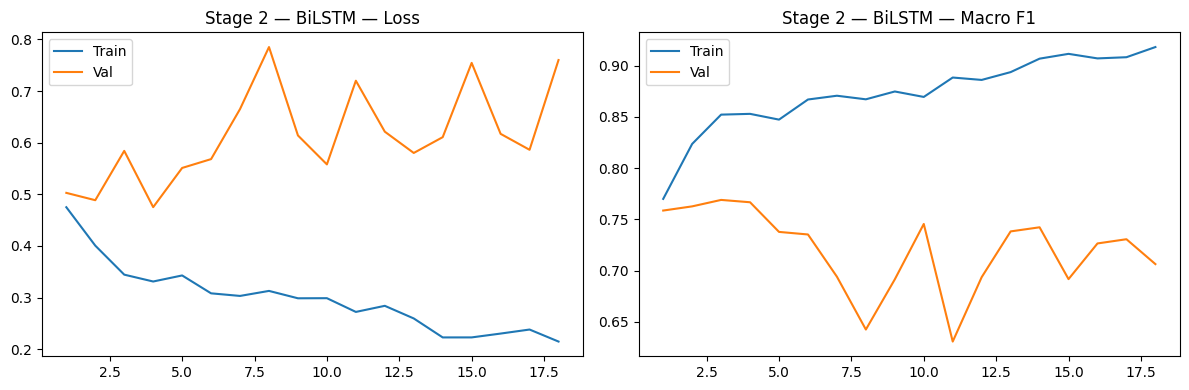


Stage 2 best val F1 : 0.7690
  Delta vs Stage 1  : +0.0331


In [ ]:
print('Training best BiLSTM on full training set...')
bilstm_model = BiLSTM(**bilstm_best_params).to(device)
bilstm_best_f1, bilstm_history = train_model(
    bilstm_model, epochs=40, lr=bilstm_best_params['lr'],
    patience=15, label='BiLSTM')

plot_history(bilstm_history, 'Stage 2 — BiLSTM')
print(f'\nStage 2 best val F1 : {bilstm_best_f1:.4f}')
print(f'  Delta vs Stage 1  : {bilstm_best_f1 - lstm_best_f1:+.4f}')

## Stage 3: BiLSTM Variants

extending upon the plain BiLSTM by checking the following all over a sahred grid. This ensures fairness

3 architectural models checked are the following:

- **3a CNN-BiLSTM:** a Conv1d encoder extracts local spectral patterns before the BiLSTM processes temporal context.
- **3b  BiLSTM with Attention:** Bahdanau-style attention replaces mean-pooling, learning to weight the most informative timesteps.
- **3c Stacked BiLSTM with skip connections:** two explicit BiLSTM layers with a residual connection from the first layer's output, giving gradients a shorter path and preserving low-level temporal features.

### 3a — CNN-BiLSTM

In [ ]:
class CNNBiLSTM(nn.Module):
    """
    Two-layer Conv1d encoder followed by a stacked BiLSTM.

    The CNN extracts local spectral patterns from the MFCC frames before
    the BiLSTM models temporal context across the cardiac cycle.

    Parameters
    ----------
    in_size      : input feature dimension (39)
    cnn_channels : number of output channels in the final CNN layer
    cnn_kernel   : convolutional kernel size
    hidden       : BiLSTM hidden size per direction
    layers       : number of stacked BiLSTM layers
    dropout      : dropout probability
    n_classes    : number of output classes

    Example
    -------
    >>> model = CNNBiLSTM()
    >>> x = torch.randn(32, 20, 39)
    >>> lengths = torch.randint(10, 20, (32,))
    >>> model(x, lengths).shape
    torch.Size([32, 2])
    """
    def __init__(self, in_size=INPUT_SIZE, cnn_channels=64, cnn_kernel=3,
                 hidden=128, layers=2, dropout=0.3, n_classes=N_CLASSES, **kwargs):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_size, cnn_channels // 2, cnn_kernel, padding=cnn_kernel // 2),
            nn.BatchNorm1d(cnn_channels // 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(cnn_channels // 2, cnn_channels, cnn_kernel, padding=cnn_kernel // 2),
            nn.BatchNorm1d(cnn_channels), nn.ReLU(), nn.Dropout(dropout),
        )
        self.bilstm = nn.LSTM(cnn_channels, hidden, layers, batch_first=True,
                              bidirectional=True,
                              dropout=dropout if layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )

    def forward(self, x, lengths):
        # x: (B, T, 39)
        x = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)
        # x: (B, T, cnn_channels)

        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.bilstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)
        # out: (B, T, hidden * 2)

        B, T, H = out.shape
        mask = (torch.arange(T, device=out.device).unsqueeze(0)
                < lengths.to(out.device).unsqueeze(1)).float()
        pooled = (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
        # pooled: (B, hidden * 2)
        return self.head(self.drop(pooled))
        # out: (B, n_classes)


print('CNNBiLSTM defined.')
print(f'  Params: {sum(p.numel() for p in CNNBiLSTM().parameters()):,}')

CNNBiLSTM defined.
  Params: 620,674


Grid search for CNN-BiLSTM — 18 configs x 2 folds
  [CNN-BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3, 'cnn_channels': 32} fold=1] Ep 010 | Train F1: 0.825  Val F1: 0.814  Best: 0.814
  [CNN-BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3, 'cnn_channels': 32} fold=1] Ep 020 | Train F1: 0.835  Val F1: 0.840  Best: 0.842
  [CNN-BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3, 'cnn_channels': 32} fold=1] Ep 030 | Train F1: 0.836  Val F1: 0.867  Best: 0.867
  [CNN-BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3, 'cnn_channels': 32} fold=1] Ep 040 | Train F1: 0.862  Val F1: 0.877  Best: 0.877
  [CNN-BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3, 'cnn_channels': 32} fold=2] Ep 010 | Train F1: 0.797  Val F1: 0.811  Best: 0.811
  [CNN-BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3, 'cnn_channels': 32} fold=2] Ep 020 | Train F1: 0.845  Val F1: 0.823  Best: 0.824
  [CNN-BiLSTM cfg={'lr': 0.0001, 'dropout': 0.3, 'cnn_channels': 32} fold=2] Ep 030 | Train F1: 0.835  Val F1: 0.829  Best: 0.832
  [CNN-BiLSTM cfg={'lr': 0.0001, 'dropou

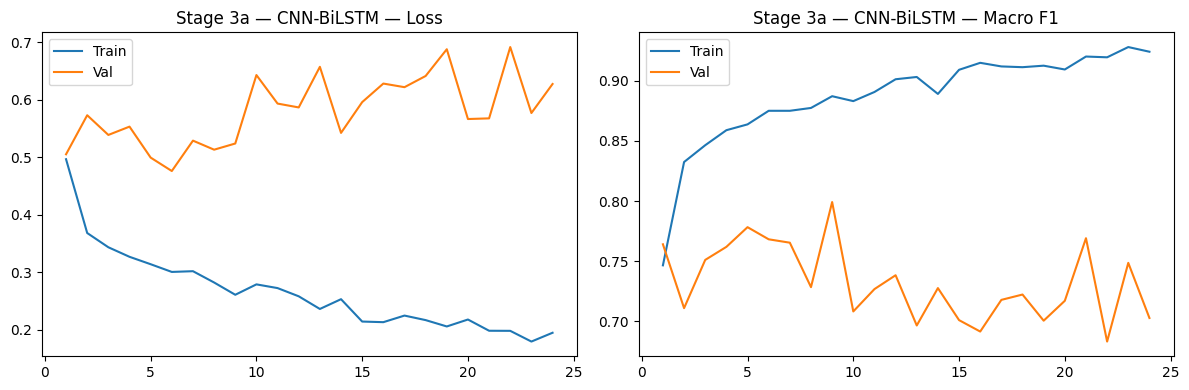


3a CNN-BiLSTM val F1: 0.7991  (delta vs BiLSTM: +0.0302)


In [ ]:
cnn_best_params = grid_search(
    build_model_fn=CNNBiLSTM,
    param_grid=CNN_GRID,
    label='CNN-BiLSTM'
)

print('\nTraining best CNN-BiLSTM...')
cnn_model = CNNBiLSTM(**cnn_best_params).to(device)
cnn_best_f1, cnn_history = train_model(
    cnn_model, epochs=40, lr=cnn_best_params['lr'],
    patience=15, label='CNN-BiLSTM')

plot_history(cnn_history, 'Stage 3a — CNN-BiLSTM')
print(f'\n3a CNN-BiLSTM val F1: {cnn_best_f1:.4f}  (delta vs BiLSTM: {cnn_best_f1 - bilstm_best_f1:+.4f})')

### 3b  BiLSTM with Attention

In [ ]:
class AttentionPool(nn.Module):
    """
    Bahdanau-style additive attention over the time axis.

    Learns a scalar score for each timestep and produces a weighted
    sum of the hidden states, masking out padding positions.

    Parameters
    ----------
    hidden_size : dimension of the input hidden states
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1)

    def forward(self, out, lengths):
        # out: (B, T, H)   lengths: (B,)
        scores = self.attn(out).squeeze(-1)
        # scores: (B, T)

        # Mask padding positions before softmax
        mask = (torch.arange(scores.size(1), device=scores.device)[None, :]
                >= lengths.to(scores.device)[:, None])
        scores = scores.masked_fill(mask, -1e9)
        weights = torch.softmax(scores, dim=1)
        # weights: (B, T)

        return (out * weights.unsqueeze(-1)).sum(1)
        # out: (B, H)


class BiLSTMAttention(nn.Module):
    """
    Stacked BiLSTM with learned attention pooling over the time axis.

    Parameters
    ----------
    in_size   : input feature dimension (39)
    hidden    : BiLSTM hidden size per direction
    layers    : number of stacked BiLSTM layers
    dropout   : dropout probability
    n_classes : number of output classes

    Example
    -------
    >>> model = BiLSTMAttention()
    >>> x = torch.randn(32, 20, 39)
    >>> lengths = torch.randint(10, 20, (32,))
    >>> model(x, lengths).shape
    torch.Size([32, 2])
    """
    def __init__(self, in_size=INPUT_SIZE, hidden=128, layers=2,
                 dropout=0.3, n_classes=N_CLASSES, **kwargs):
        super().__init__()
        self.bilstm = nn.LSTM(in_size, hidden, layers, batch_first=True,
                              bidirectional=True,
                              dropout=dropout if layers > 1 else 0.0)
        self.attn_pool = AttentionPool(hidden * 2)
        self.norm = nn.LayerNorm(hidden * 2)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes)
        )

    def forward(self, x, lengths):
        # x: (B, T, 39)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.bilstm(packed)
        out, _ = pad_packed_sequence(out, batch_first=True)
        # out: (B, T, hidden * 2)

        pooled = self.attn_pool(out, lengths)
        # pooled: (B, hidden * 2)
        return self.head(self.drop(self.norm(pooled)))
        # out: (B, n_classes)


print('BiLSTMAttention defined.')
print(f'  Params: {sum(p.numel() for p in BiLSTMAttention().parameters()):,}')

BiLSTMAttention defined.
  Params: 585,667


Grid search for BiLSTM-Attention — 8 configs x 2 folds
  [BiLSTM-Attention cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 010 | Train F1: 0.821  Val F1: 0.833  Best: 0.833
  [BiLSTM-Attention cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 020 | Train F1: 0.855  Val F1: 0.858  Best: 0.859
  [BiLSTM-Attention cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 030 | Train F1: 0.908  Val F1: 0.872  Best: 0.880
  [BiLSTM-Attention cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 040 | Train F1: 0.904  Val F1: 0.883  Best: 0.890
  [BiLSTM-Attention cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 010 | Train F1: 0.841  Val F1: 0.840  Best: 0.840
  [BiLSTM-Attention cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 020 | Train F1: 0.874  Val F1: 0.861  Best: 0.862
  [BiLSTM-Attention cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 030 | Train F1: 0.898  Val F1: 0.858  Best: 0.880
  [BiLSTM-Attention cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Early stop @ ep 38  best val F1=0.8804
  params={'lr': 0.0001, 'dropou

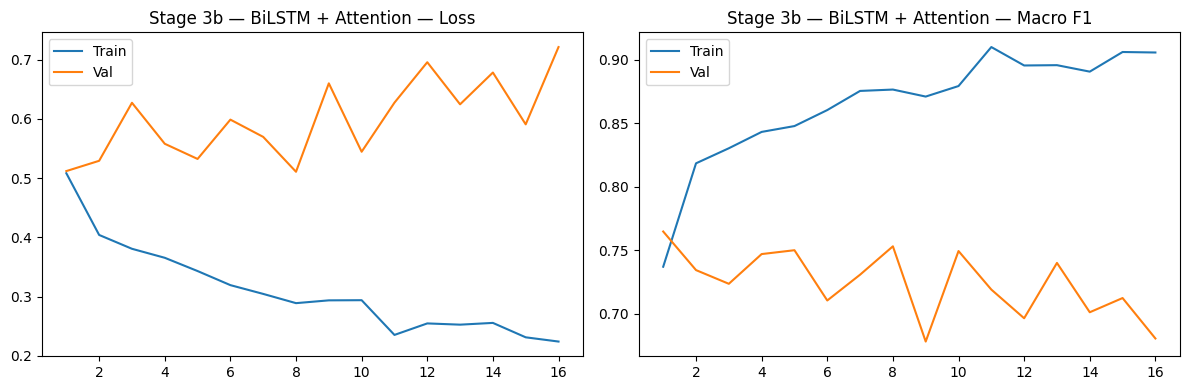


3b BiLSTM-Attention val F1: 0.7647  (delta vs BiLSTM: -0.0043)


In [ ]:
attn_best_params = grid_search(
    build_model_fn=BiLSTMAttention,
    param_grid=SHARED_GRID,
    label='BiLSTM-Attention'
)

print('\nTraining best BiLSTM-Attention...')
attn_model = BiLSTMAttention(**attn_best_params).to(device)
attn_best_f1, attn_history = train_model(
    attn_model, epochs=40, lr=attn_best_params['lr'],
    patience=15, label='BiLSTM-Attention')

plot_history(attn_history, 'Stage 3b — BiLSTM + Attention')
print(f'\n3b BiLSTM-Attention val F1: {attn_best_f1:.4f}  (delta vs BiLSTM: {attn_best_f1 - bilstm_best_f1:+.4f})')

### 3c Stacked BiLSTM with Skip Connections

In [ ]:
class SkipBiLSTM(nn.Module):
    """
    Two explicit BiLSTM layers with a residual connection from the first
    layer's output to the classifier input.

    The skip connection gives gradients a shorter path and preserves
    low-level temporal features alongside deeper representations.
    After mean-pooling both layers, the two pooled vectors are concatenated
    before the classification head.

    Parameters
    ----------
    in_size   : input feature dimension (39)
    hidden    : BiLSTM hidden size per direction
    dropout   : dropout probability
    n_classes : number of output classes

    Example
    -------
    >>> model = SkipBiLSTM()
    >>> x = torch.randn(32, 20, 39)
    >>> lengths = torch.randint(10, 20, (32,))
    >>> model(x, lengths).shape
    torch.Size([32, 2])
    """
    def __init__(self, in_size=INPUT_SIZE, hidden=128,
                 dropout=0.3, n_classes=N_CLASSES, **kwargs):
        super().__init__()
        self.lstm1 = nn.LSTM(in_size, hidden, 1, batch_first=True, bidirectional=True)
        self.norm1  = nn.LayerNorm(hidden * 2)
        self.drop1  = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden * 2, hidden, 1, batch_first=True, bidirectional=True)
        self.norm2  = nn.LayerNorm(hidden * 2)
        self.drop2  = nn.Dropout(dropout)
        # Concatenation of both layers' mean-pools: 2 x (hidden * 2)
        self.head = nn.Sequential(
            nn.Linear(hidden * 4, 128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, n_classes)
        )

    def _mean_pool(self, out, lengths):
        mask = (torch.arange(out.size(1), device=out.device)[None, :]
                < lengths.to(out.device)[:, None]).float()
        return (out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)

    def forward(self, x, lengths):
        # x: (B, T, 39)
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)

        out1, _ = self.lstm1(packed)
        out1, _ = pad_packed_sequence(out1, batch_first=True)
        # out1: (B, T, hidden * 2)
        out1 = self.drop1(self.norm1(out1))
        skip = self._mean_pool(out1, lengths)
        # skip: (B, hidden * 2)  <- skip connection pulled here

        packed2 = pack_padded_sequence(out1, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out2, _ = self.lstm2(packed2)
        out2, _ = pad_packed_sequence(out2, batch_first=True)
        # out2: (B, T, hidden * 2)
        out2 = self.drop2(self.norm2(out2))
        pool2 = self._mean_pool(out2, lengths)
        # pool2: (B, hidden * 2)

        combined = torch.cat([skip, pool2], dim=-1)
        # combined: (B, hidden * 4)
        return self.head(combined)
        # out: (B, n_classes)


print('SkipBiLSTM defined.')
print(f'  Params: {sum(p.numel() for p in SkipBiLSTM().parameters()):,}')

SkipBiLSTM defined.
  Params: 635,266


Grid search for SkipBiLSTM — 8 configs x 2 folds
  [SkipBiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 010 | Train F1: 0.838  Val F1: 0.842  Best: 0.842
  [SkipBiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 020 | Train F1: 0.873  Val F1: 0.866  Best: 0.869
  [SkipBiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 030 | Train F1: 0.897  Val F1: 0.883  Best: 0.883
  [SkipBiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=1] Ep 040 | Train F1: 0.920  Val F1: 0.898  Best: 0.898
  [SkipBiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 010 | Train F1: 0.848  Val F1: 0.842  Best: 0.842
  [SkipBiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 020 | Train F1: 0.874  Val F1: 0.862  Best: 0.862
  [SkipBiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 030 | Train F1: 0.908  Val F1: 0.862  Best: 0.871
  [SkipBiLSTM cfg={'lr': 0.0001, 'dropout': 0.3} fold=2] Ep 040 | Train F1: 0.927  Val F1: 0.886  Best: 0.886
  params={'lr': 0.0001, 'dropout': 0.3}  ->  mean F1=0.8921 +/- 0.0060


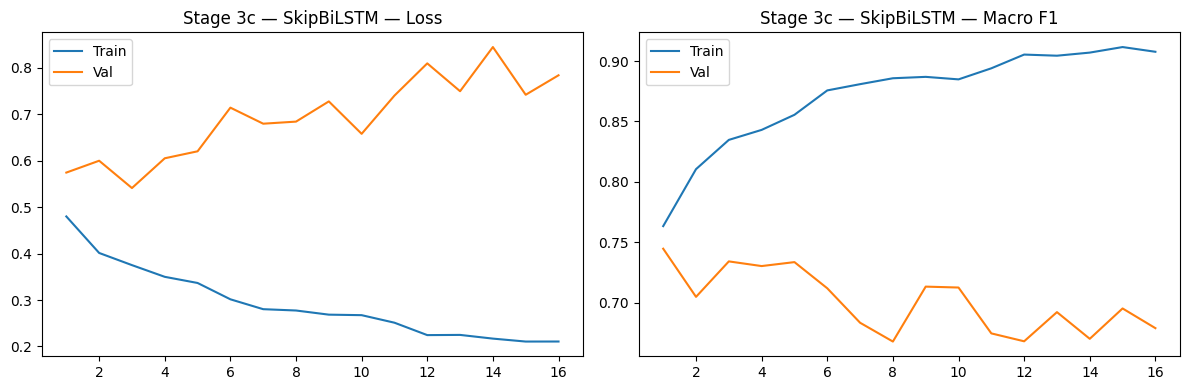


3c SkipBiLSTM val F1: 0.7447


In [ ]:
skip_best_params = grid_search(
    build_model_fn=SkipBiLSTM,
    param_grid=SHARED_GRID,
    label='SkipBiLSTM'
)

print('\nTraining best SkipBiLSTM...')
skip_model = SkipBiLSTM(**skip_best_params).to(device)
skip_best_f1, skip_history = train_model(
    skip_model, epochs=40, lr=skip_best_params['lr'],
    patience=15, label='SkipBiLSTM')

plot_history(skip_history, 'Stage 3c — SkipBiLSTM')
print(f'\n3c SkipBiLSTM val F1: {skip_best_f1:.4f}')

## Part 1 now running the Test F1 Summary

evaluates arhcitecture based on the held out of test performance, overfitting is wild by testing on test set hope to pick best base architecture

In [ ]:
# Part 1 Test F1 Summary
# Evaluate each Stage 1-3 model on the held-out test set and display results.

import pandas as pd
from sklearn.metrics import f1_score

def test_f1(model):
    """Return macro F1 on the held-out test set."""
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for x, lengths, y in test_loader:
            x, lengths = x.to(device), lengths.to(device)
            logits = model(x, lengths)
            preds.extend(logits.argmax(1).cpu().numpy())
            targets.extend(y.numpy())
    return f1_score(targets, preds, average="macro", zero_division=0)

architectures = [
    ("Stage 1",  "Vanilla LSTM",          lstm_model),
    ("Stage 2",  "BiLSTM",                bilstm_model),
    ("Stage 3a", "CNN-BiLSTM",            cnn_model),
    ("Stage 3b", "BiLSTM + Attention",    attn_model),
    ("Stage 3c", "Stacked BiLSTM + Skip", skip_model),
]

rows = []
for stage, name, model in architectures:
    f1 = test_f1(model)
    rows.append({"Stage": stage, "Architecture": name, "Test Macro F1": round(f1, 4)})

summary_df = pd.DataFrame(rows)
best_idx   = summary_df["Test Macro F1"].idxmax()
summary_df["Best"] = ""
summary_df.loc[best_idx, "Best"] = "★"


print(" Part 1 — Architecture Test F1 Comparison")
print("="*55)
print(summary_df.to_string(index=False))
print("="*55)
print(f" Winner: {summary_df.loc[best_idx, 'Architecture']}  (Test Macro F1 = {summary_df.loc[best_idx, 'Test Macro F1']:.4f})")

 Part 1 — Architecture Test F1 Comparison
   Stage          Architecture  Test Macro F1 Best
 Stage 1          Vanilla LSTM         0.5466     
 Stage 2                BiLSTM         0.5676     
Stage 3a            CNN-BiLSTM         0.6331    ★
Stage 3b    BiLSTM + Attention         0.5769     
Stage 3c Stacked BiLSTM + Skip         0.5599     
 Winner: CNN-BiLSTM  (Test Macro F1 = 0.6331)


# Part 2: CNN_BiLSTM + Dilated Skip Hyperparameter Tuning

CNN_BiLSTM was selected as the best architecture in Part 1.
This part goes through the following experiments as part of finding the best hyperparameter configuration.

The experiments applied are as follows.

- testing adding Dilated CNN with dilations 1, 2, and 4: widens the receptive field without collapsing the time axis.
- testing adding of Skip connections on every BiLSTM layer: residual gradients prevent vanishing in deeper stacks.
- teasting adding Hybrid pooling (attention + mean): attention finds the most diagnostic frames while mean anchors generalisation.
- testing a  gradient clip 0.5 (was 1.0): tighter clipping stabilises training on this small dataset.
- testing hidden sizes of 192 (was 128): more capacity now that regularisation is solid.


## Dataset, DataLoader and Class Weights


In [ ]:
# data loading we'd like to check how hop does so we extract hop=64 data
from google.colab import drive
import pickle
drive.mount('/content/drive')

SAVE_DIR = Path('/content/drive/MyDrive/circor_processed')
SAVE_DIR.mkdir(exist_ok=True)

if (SAVE_DIR / 'cycles_v2.pkl').exists():
    # ── Fast path: load pre-extracted hop=64 data ──────────────────────────
    with open(SAVE_DIR / 'cycles_v2.pkl', 'rb') as f:
        data = pickle.load(f)
    X_train, y_train = data['X_train'], data['y_train']
    X_val,   y_val   = data['X_val'],   data['y_val']
    X_test,  y_test  = data['X_test'],  data['y_test']
    meta_df          = data['meta_df']
    train_pids       = data['train_pids']
    val_pids         = data['val_pids']
    test_pids        = data['test_pids']
    print(f'✓ Loaded from Drive (cycles_v2.pkl)')
    print(f'  Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')
    print(f'  Sample shape: {X_train[0].shape}  ← must be (T, 39) with T roughly doubled vs hop=128')
else:
    print('cycles_v2.pkl not found — run Cells 1b–1d to extract from scratch, then re-run this cell.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Loaded from Drive (cycles_v2.pkl)
  Train: 8882  Val: 1568  Test: 1962
  Sample shape: (20, 39)  ← must be (T, 39) with T roughly doubled vs hop=128


In [ ]:
# if not loaded before then fresh extraction from Drive WAV
# ── 1b: Locate dataset ────────────────────────────────────────────────────────
SEARCH_ROOT = Path('/content/drive/MyDrive/st311_code_plus_data-20260501T162242Z-3-001/st311_code_plus_data/'
                   'the-circor-digiscope-phonocardiogram-dataset-1.0.3/the-circor-data')
csv_candidates = list(SEARCH_ROOT.rglob('training_data.csv'))
assert len(csv_candidates) > 0, f'training_data.csv not found under {SEARCH_ROOT}'

csv_path  = csv_candidates[0]
DATA_DIR  = csv_path.parent
TRAIN_DIR = DATA_DIR / 'training_data'
print(f'CSV: {csv_path}')
print(f'WAVs found: {len(list(TRAIN_DIR.glob("*.wav")))}')

# ── 1c: Build per-recording table ─────────────────────────────────────────────
df = pd.read_csv(str(csv_path))
df = df[df['Murmur'] == 'Present'].copy()

GRADE_MAP = {
    'I/VI': 'Soft', 'II/VI': 'Soft',
    'III/VI': 'Loud', 'IV/VI': 'Loud', 'V/VI': 'Loud', 'VI/VI': 'Loud',
}
df['recording_class'] = df['Systolic murmur grading'].map(GRADE_MAP)
df = df[df['recording_class'].notna()].copy()
print(f'Patients: {len(df)}  |  {df["recording_class"].value_counts().to_dict()}')

rows = []
for _, row in df.iterrows():
    pid  = str(row['Patient ID'])
    locs = str(row['Recording locations:']).split('+')
    for loc in locs:
        loc = loc.strip()
        wav = TRAIN_DIR / f'{pid}_{loc}.wav'
        tsv = TRAIN_DIR / f'{pid}_{loc}.tsv'
        if wav.exists() and tsv.exists():
            rows.append({'patient_id': pid, 'location': loc,
                         'wav_path': wav, 'tsv_path': tsv,
                         'recording_class': row['recording_class']})
rec_df = pd.DataFrame(rows)
print(f'Recordings: {len(rec_df)}  |  {rec_df["recording_class"].value_counts().to_dict()}')
# ── 1d: Feature extraction — hop_length=64 (KEY FIX) ─────────────────────────
# hop=64 at sr=2000 → ~31 frames per 1s cycle vs ~16 with hop=128
# This matches the Stacked BiLSTM's temporal resolution exactly.
TARGET_SR  = 2000
N_MFCC     = 13
HOP_LENGTH = 64    # <── KEY FIX: was 128
N_FFT      = 256

def extract_cycles_mfcc(wav_path, tsv_path,
                        target_sr=TARGET_SR, n_mfcc=N_MFCC,
                        min_dur=0.2, max_dur=2.0):
    audio, _ = librosa.load(str(wav_path), sr=target_sr)
    seg = pd.read_csv(str(tsv_path), sep='\t', header=None,
                      names=['start', 'end', 'label'])
    seg['label'] = seg['label'].astype(int)
    s1 = seg[seg['label'] == 1].reset_index(drop=True)
    cycles = []
    for i in range(len(s1) - 1):
        start_sec = float(s1.loc[i,   'start'])
        end_sec   = float(s1.loc[i+1, 'start'])
        dur = end_sec - start_sec
        if not (min_dur <= dur <= max_dur):
            continue
        cycle = audio[int(start_sec * target_sr):int(end_sec * target_sr)]
        if len(cycle) < N_FFT:
            continue
        mfcc   = librosa.feature.mfcc(y=cycle, sr=target_sr, n_mfcc=n_mfcc,
                                       hop_length=HOP_LENGTH, n_fft=N_FFT)
        # Adaptive width for delta so short cycles don't error
        n_frames = mfcc.shape[1]
        width    = max(3, min(9, n_frames if n_frames % 2 == 1 else n_frames - 1))
        delta    = librosa.feature.delta(mfcc, width=width)
        delta2   = librosa.feature.delta(mfcc, order=2, width=width)
        feat     = np.vstack([mfcc, delta, delta2])   # (39, T)
        cycles.append(feat.T)                         # (T, 39)
    return cycles

all_cycles, all_labels, all_meta = [], [], []
skipped, errors = 0, []
for _, row in rec_df.iterrows():
    try:
        cycles = extract_cycles_mfcc(row['wav_path'], row['tsv_path'])
        if not cycles:
            skipped += 1; continue
    except Exception as e:
        skipped += 1; errors.append((str(row['wav_path'].name), str(e))); continue
    for c in cycles:
        all_cycles.append(c)
        all_labels.append(row['recording_class'])
        all_meta.append((row['patient_id'], row['location']))

print(f'Cycles extracted: {len(all_cycles)}  |  skipped: {skipped}')
print(Counter(all_labels))
if errors: print(f'First error: {errors[0]}')
assert len(all_cycles) > 0

# ── 1e: Patient-wise 70/15/15 split ──────────────────────────────────────────
label_arr = np.array(all_labels)
meta_df   = pd.DataFrame(all_meta, columns=['patient_id', 'location'])
meta_df['label']     = label_arr
meta_df['cycle_idx'] = np.arange(len(all_cycles))

patient_class = (
    meta_df.groupby('patient_id')['label']
    .agg(lambda x: x.value_counts().index[0])
    .reset_index()
    .rename(columns={'label': 'dominant_class'})
)

train_pids, temp_pids = train_test_split(
    patient_class['patient_id'],
    test_size=0.30, stratify=patient_class['dominant_class'], random_state=42)
temp_class = patient_class[patient_class['patient_id'].isin(temp_pids)]
val_pids, test_pids = train_test_split(
    temp_class['patient_id'],
    test_size=0.50, stratify=temp_class['dominant_class'], random_state=42)

def get_split(pids):
    idx = meta_df[meta_df['patient_id'].isin(pids)]['cycle_idx'].values
    return [all_cycles[i] for i in idx], np.array([all_labels[i] for i in idx])

X_train, y_train = get_split(train_pids)
X_val,   y_val   = get_split(val_pids)
X_test,  y_test  = get_split(test_pids)

print(f'\nTrain: {len(X_train)} ({Counter(y_train)})')
print(f'Val:   {len(X_val)}   ({Counter(y_val)})')
print(f'Test:  {len(X_test)}  ({Counter(y_test)})')
print(f'Sample shape: {X_train[0].shape}  ← should be (T, 39) with larger T than before')

# Save for next session
with open(SAVE_DIR / 'cycles_v2.pkl', 'wb') as f:
    pickle.dump({'X_train': X_train, 'y_train': y_train,
                 'X_val': X_val, 'y_val': y_val,
                 'X_test': X_test, 'y_test': y_test,
                 'meta_df': meta_df,
                 'train_pids': list(train_pids),
                 'val_pids':   list(val_pids),
                 'test_pids':  list(test_pids)}, f)
print('✓ Saved cycles_v2.pkl to Drive')



In [ ]:
le = LabelEncoder()
le.fit(['Soft', 'Loud'])
class_names = le.classes_.tolist()
print(f'Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

class_weights        = compute_class_weight('balanced', classes=le.classes_, y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f'Class weights: { {c: round(w,3) for c,w in zip(le.classes_, class_weights)} }')

INPUT_SIZE = X_train[0].shape[1]   # 39
N_CLASSES  = 2
print(f'Input feature dim: {INPUT_SIZE}')

class CycleDataset(Dataset):
    def __init__(self, cycles, labels):
        self.cycles = [torch.tensor(c, dtype=torch.float32) for c in cycles]
        self.labels = torch.tensor(le.transform(labels), dtype=torch.long)
    def __len__(self): return len(self.cycles)
    def __getitem__(self, idx): return self.cycles[idx], self.labels[idx]

def collate_fn(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([s.shape[0] for s in seqs])
    padded  = pad_sequence(seqs, batch_first=True)
    return padded, lengths, torch.stack(labels)

def make_loaders(batch_size=64, balanced_train=True):
    y_enc = le.transform(y_train)
    if balanced_train:
        counts  = np.bincount(y_enc)
        weights = torch.tensor([1.0 / counts[yi] for yi in y_enc])
        sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
        train_ld = DataLoader(CycleDataset(X_train, y_train),
                              batch_size=batch_size, sampler=sampler, collate_fn=collate_fn)
    else:
        train_ld = DataLoader(CycleDataset(X_train, y_train),
                              batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_ld  = DataLoader(CycleDataset(X_val,  y_val),  batch_size=batch_size*2,
                         shuffle=False, collate_fn=collate_fn)
    test_ld = DataLoader(CycleDataset(X_test, y_test), batch_size=batch_size*2,
                         shuffle=False, collate_fn=collate_fn)
    return train_ld, val_ld, test_ld

train_loader, val_loader, test_loader = make_loaders(batch_size=64)
print(f'Loaders ready — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}')
results_table = []



Label encoding: {np.str_('Loud'): np.int64(0), np.str_('Soft'): np.int64(1)}
Class weights: {np.str_('Loud'): np.float64(1.484), np.str_('Soft'): np.float64(0.754)}
Input feature dim: 39
Loaders ready — train: 139  val: 13  test: 16


## CNN_BiLSTM : Dilated Skip with Skip Connections and Hybrid Pooling

The full pipeline is:

```
(B, T, 39)
  -> DilatedCNNBlock  [dilations 1, 2, 4 — wide receptive field, frames preserved]
  -> SkipBiLSTMLayer x lstm_layers  [residual + LayerNorm on each BiLSTM layer]
  -> HybridPool  [attention-weighted context + masked mean -> concatenated]
  -> FC head
```



In [ ]:
# ── Dilated CNN block ──────────────────────────────────────────────────────────
class DilatedCNNBlock(nn.Module):
    """
    Three parallel Conv1d branches with dilations 1, 2, 4 to capture local
    spectral texture (d=1), inter-phoneme patterns (d=2), and full-cycle
    structure (d=4).  Outputs are summed, then BN + ReLU + Dropout.

    Using kernel=5 and dilation up to 4 gives effective receptive field
    of 5 + 4*(5-1) = 21 frames ≈ 0.67 s at hop=64, covering one full
    cardiac cycle without pooling or striding — sequence length is preserved.
    """
    def __init__(self, in_channels, out_channels, kernel=5, dropout=0.3):
        super().__init__()
        pad1 = kernel // 2
        pad2 = kernel // 2 * 2
        pad4 = kernel // 2 * 4
        self.branch1 = nn.Conv1d(in_channels, out_channels, kernel,
                                  padding=pad1, dilation=1)
        self.branch2 = nn.Conv1d(in_channels, out_channels, kernel,
                                  padding=pad2, dilation=2)
        self.branch4 = nn.Conv1d(in_channels, out_channels, kernel,
                                  padding=pad4, dilation=4)
        self.bn   = nn.BatchNorm1d(out_channels)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # x: (B, C, T)
        out = self.branch1(x) + self.branch2(x) + self.branch4(x)
        return self.drop(F.relu(self.bn(out)))


# ── BiLSTM layer with skip connection + LayerNorm ─────────────────────────────
class SkipBiLSTMLayer(nn.Module):
    """
    One BiLSTM layer with additive residual from its input.
    Matches the core mechanism of SkipBiLSTMBlock used by the Stacked BiLSTM
    that outperformed the original CNN-BiLSTM.

    Skip: project input to match BiLSTM output dim → add → LayerNorm.
    """
    def __init__(self, input_size, hidden_size, dropout=0.3):
        super().__init__()
        self.bilstm   = nn.LSTM(input_size, hidden_size,
                                batch_first=True, bidirectional=True)
        self.out_size  = hidden_size * 2
        self.skip_proj = (nn.Linear(input_size, self.out_size)
                          if input_size != self.out_size else nn.Identity())
        self.norm      = nn.LayerNorm(self.out_size)
        self.drop      = nn.Dropout(dropout)

    def forward(self, x, lengths):
        packed      = pack_padded_sequence(x, lengths.cpu(),
                                           batch_first=True, enforce_sorted=False)
        out_packed, _ = self.bilstm(packed)
        out, _      = pad_packed_sequence(out_packed, batch_first=True,
                                          total_length=x.size(1))
        residual    = self.skip_proj(x)
        return self.drop(self.norm(out + residual))


# ── Hybrid pooling: attention + masked mean ────────────────────────────────────
class HybridPool(nn.Module):
    """
    Concatenates two pooling strategies over the sequence:
      • Attention pool  — Bahdanau-style, selects the most diagnostic frames
      • Masked mean pool — stable, low-variance average over valid frames
    Output dim = 2 × hidden_size.

    Why hybrid: on small datasets attention alone can overfit; mean alone
    discards temporal salience.  Concatenation gives the FC head both signals.
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, out, lengths):
        # Attention pool
        scores = self.attn(out).squeeze(-1)                              # (B, T)
        mask   = (torch.arange(scores.size(1), device=scores.device)
                  .unsqueeze(0) >= lengths.to(scores.device).unsqueeze(1))
        scores = scores.masked_fill(mask, -1e9)
        w      = torch.softmax(scores, dim=1)
        attn_out = (out * w.unsqueeze(-1)).sum(1)                        # (B, H)

        # Masked mean pool
        float_mask = (~mask).float().unsqueeze(-1)                       # (B, T, 1)
        mean_out   = (out * float_mask).sum(1) / float_mask.sum(1).clamp(min=1)

        return torch.cat([attn_out, mean_out], dim=1)                    # (B, 2H)


# ── Full model ─────────────────────────────────────────────────────────────────
class CNN_BiLSTM_DilatedSkip(nn.Module):
    """
    CNN-BiLSTM Dilated Skip:
      • DilatedCNNBlock (dilations 1,2,4) — richer spectral features, no frame collapse
      • SkipBiLSTMLayer × lstm_layers     — residual gradient flow per layer
      • HybridPool (attention + mean)     — robust to small data, retains temporal focus
      • FC head with LayerNorm

    All structural fixes over the original CNN-BiLSTM are applied here.
    """
    def __init__(self, input_size=39, cnn_channels=64, cnn_kernel=5,
                 lstm_hidden=192, lstm_layers=2, fc_hidden=192,
                 num_classes=2, dropout=0.3):
        super().__init__()

        # Dilated CNN
        self.cnn = DilatedCNNBlock(input_size, cnn_channels,
                                    kernel=cnn_kernel, dropout=dropout)

        # Stacked skip-BiLSTM layers
        self.bilstm_layers = nn.ModuleList()
        in_size = cnn_channels
        for _ in range(lstm_layers):
            layer = SkipBiLSTMLayer(in_size, lstm_hidden, dropout=dropout)
            self.bilstm_layers.append(layer)
            in_size = layer.out_size   # 2 * lstm_hidden

        # Hybrid pooling — output is 2 × in_size
        self.pool = HybridPool(in_size)
        pool_out  = in_size * 2

        # FC classifier
        self.head = nn.Sequential(
            nn.LayerNorm(pool_out),
            nn.Dropout(dropout),
            nn.Linear(pool_out, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )

    def forward(self, x, lengths):
        # CNN: (B,T,39) → (B,T,cnn_channels)
        x = self.cnn(x.permute(0, 2, 1)).permute(0, 2, 1)

        # Stack of skip-BiLSTM layers
        for layer in self.bilstm_layers:
            x = layer(x, lengths)

        # Hybrid pool → FC
        pooled = self.pool(x, lengths)
        return self.head(pooled)


# ── Sanity check ──────────────────────────────────────────────────────────────
_m = CNN_BiLSTM_DilatedSkip(input_size=INPUT_SIZE).to(device)
_x = torch.randn(4, 40, 39).to(device)   # T=40 (longer seqs from hop=64)
_l = torch.tensor([40, 30, 20, 15]).to(device)
assert _m(_x, _l).shape == (4, 2), 'Forward pass shape mismatch'
n_p = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'✓ CNN_BiLSTM_DilatedSkip defined  |  trainable params: {n_p:,}')
del _m, _x, _l


✓ CNN_BiLSTM_DilatedSkip defined  |  trainable params: 1,498,306


## Training and Evaluation Functions


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, train=True):
    """
    Run one epoch of training or evaluation.

    Parameters
    ----------
    model     : nn.Module
    loader    : DataLoader
    criterion : loss function
    optimizer : required if train=True
    train     : if True, runs backprop and parameter updates

    Returns
    -------
    mean_loss : float
    macro_f1  : float
    """
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels_list = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, lengths, y in loader:
            x, lengths, y = x.to(device), lengths.to(device), y.to(device)
            logits = model(x, lengths)
            loss   = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels_list.extend(y.cpu().tolist())
    return (total_loss / len(loader.dataset),
            f1_score(all_labels_list, all_preds, average='macro', zero_division=0))


def train_model2(model, train_ld, val_ld, epochs=80, lr=5e-4,
                patience=15, label='', label_smoothing=0.05):
    """
    Train with AdamW and cosine annealing with warm restarts. Saves the
    checkpoint with the best validation macro F1.

    Parameters
    ----------
    model           : nn.Module
    train_ld        : training DataLoader
    val_ld          : validation DataLoader
    epochs          : maximum training epochs
    lr              : initial learning rate
    patience        : early stopping patience
    label           : string label for progress output
    label_smoothing : label smoothing coefficient for cross-entropy

    Returns
    -------
    history     : dict with train_loss, val_loss, train_f1, val_f1
    best_val_f1 : float
    """
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor,
                                     label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    # Warm restarts: T_0=20 resets the LR every 20 epochs, giving the
    # model several chances to escape local minima on this small dataset.
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=1, eta_min=1e-6)

    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1, patience_ctr, best_state = 0.0, 0, None

    print(f'\n{label}')
    print(f'  Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')
    print(f'  {"Epoch":>5} {"Train Loss":>11} {"Train F1":>9} {"Val Loss":>9} {"Val F1":>8}')

    for epoch in range(1, epochs + 1):
        tr_loss, tr_f1 = run_epoch(model, train_ld, criterion, optimizer, train=True)
        vl_loss, vl_f1 = run_epoch(model, val_ld,   criterion, train=False)
        scheduler.step()
        history['train_loss'].append(tr_loss); history['val_loss'].append(vl_loss)
        history['train_f1'].append(tr_f1);     history['val_f1'].append(vl_f1)
        print(f'  {epoch:>5} {tr_loss:>11.4f} {tr_f1:>9.4f} {vl_loss:>9.4f} {vl_f1:>8.4f}')
        if vl_f1 > best_val_f1:
            best_val_f1  = vl_f1
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  Early stopping at epoch {epoch}  (best val F1: {best_val_f1:.4f})')
                break

    model.load_state_dict(best_state)
    print(f'  Best val macro F1: {best_val_f1:.4f}')
    return history, best_val_f1


def evaluate_model(model, test_ld, label=''):
    """
    Evaluate on the test set at both cycle level and recording level.

    Recording-level predictions are produced by majority vote over all
    cycles from the same recording.

    Parameters
    ----------
    model   : nn.Module with best weights loaded
    test_ld : test DataLoader
    label   : string label for output

    Returns
    -------
    cycle_f1, rec_f1 : float
    all_preds, all_labels_list, all_probs, rec_preds, rec_trues
    """
    model.eval()
    all_preds, all_labels_list, all_probs = [], [], []
    with torch.no_grad():
        for x, lengths, y in test_ld:
            x, lengths = x.to(device), lengths.to(device)
            logits = model(x, lengths)
            probs  = F.softmax(logits, dim=1)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels_list.extend(y.tolist())
            all_probs.extend(probs.cpu().tolist())

    cycle_f1 = f1_score(all_labels_list, all_preds, average='macro', zero_division=0)

    test_meta         = meta_df[meta_df['patient_id'].isin(test_pids)].copy().reset_index(drop=True)
    test_meta         = test_meta.iloc[:len(all_preds)].copy()
    test_meta['pred'] = all_preds
    test_meta['true'] = all_labels_list
    rec_preds, rec_trues = [], []
    for (pid, loc), group in test_meta.groupby(['patient_id', 'location']):
        rec_preds.append(Counter(group['pred']).most_common(1)[0][0])
        rec_trues.append(group['true'].iloc[0])

    rec_f1 = f1_score(rec_trues, rec_preds, average='macro', zero_division=0)
    print(f'\n{label}')
    print(f'  Cycle-level     Macro F1: {cycle_f1:.4f}')
    print(f'  Recording-level Macro F1: {rec_f1:.4f}')
    return cycle_f1, rec_f1, all_preds, all_labels_list, all_probs, rec_preds, rec_trues


def plot_training(history, label=''):
    """
    Plot training and validation loss and macro F1 curves.

    Parameters
    ----------
    history : dict with keys train_loss, val_loss, train_f1, val_f1
    label   : string used in the plot title and saved filename
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='Train')
    ax1.plot(history['val_loss'],   label='Val')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
    ax2.plot(history['train_f1'], label='Train')
    ax2.plot(history['val_f1'],   label='Val')
    ax2.set_title('Macro F1'); ax2.set_xlabel('Epoch'); ax2.legend()
    plt.suptitle(f'CNN_BiLSTM — Dilated Skip — {label}')
    plt.tight_layout()
    fname = f'curves_{label.replace(" ","_").lower()}.png'
    plt.savefig(fname, dpi=150); plt.show(); print(f'Saved: {fname}')


def plot_confusion(preds, labels, label='', level='Cycle'):
    """
    Plot a confusion matrix heatmap.

    Parameters
    ----------
    preds  : list of predicted class indices
    labels : list of true class indices
    label  : string label for title and filename
    level  : 'Cycle' or 'Recording'
    """
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'CNN_BiLSTM — Dilated Skip — {level}-level ({label})')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    fname = f'cm_{level.lower()}_{label.replace(" ","_").lower()}.png'
    plt.savefig(fname, dpi=150); plt.show()


print('All functions defined.')


All functions defined.


## Hyperparameter Experiments

 The best model is selected by recording-level macro F1. All experiments share the same architecture fixes, the only varyong factors are the hyperparameters


### Experiment 1: CNN_BiLSTM + Dilated Skip Baseline

`cnn_channels=64, lstm_hidden=192, dropout=0.3, lr=5e-4, batch_size=64`

forms a reference point with all architecture fixes applied.



Exp 1 — Dilated Skip Baseline
  Params: 1,498,306
  Epoch  Train Loss  Train F1  Val Loss   Val F1
      1      0.4327    0.7759    0.5123   0.7757
      2      0.3598    0.8455    0.5203   0.7815
      3      0.3308    0.8631    0.4473   0.8370
      4      0.3073    0.8816    0.4698   0.8315
      5      0.2845    0.8962    0.5613   0.8311
      6      0.2553    0.9190    0.5227   0.8487
      7      0.2495    0.9235    0.5817   0.8091
      8      0.2364    0.9282    0.5159   0.8447
      9      0.2264    0.9348    0.4990   0.8399
     10      0.2135    0.9427    0.6649   0.8089
     11      0.2012    0.9510    0.6337   0.8245
     12      0.2026    0.9520    0.6348   0.8168
     13      0.1917    0.9595    0.6022   0.8353
     14      0.1865    0.9609    0.5686   0.8461
     15      0.1806    0.9628    0.5877   0.8428
     16      0.1715    0.9678    0.5924   0.8444
     17      0.1771    0.9669    0.5717   0.8422
     18      0.1678    0.9715    0.6125   0.8446
     19      0.164

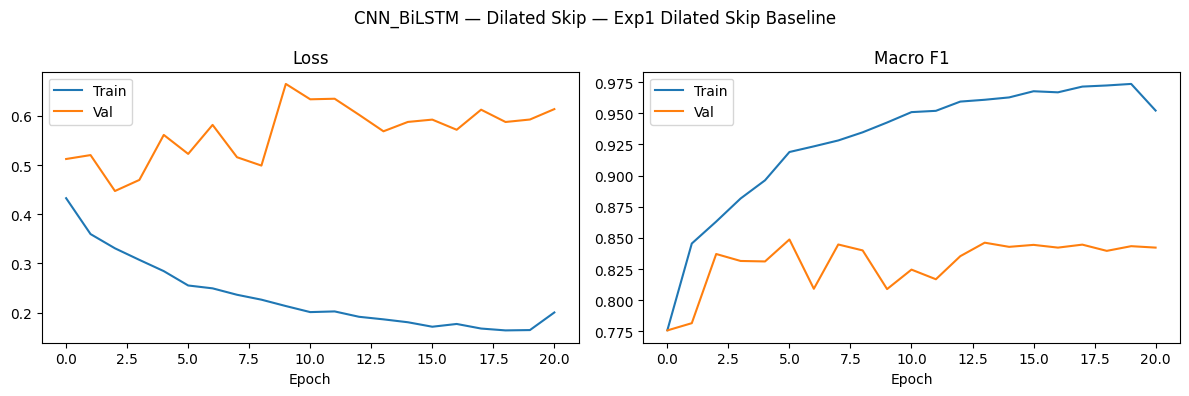

Saved: curves_exp1_dilated_skip_baseline.png


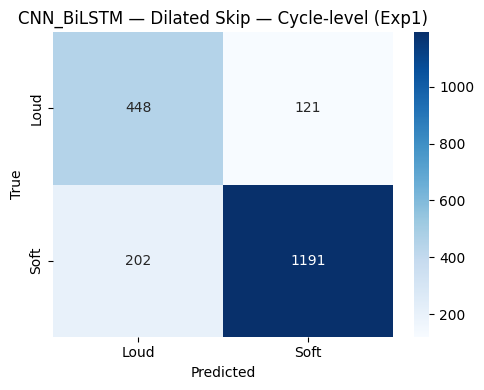

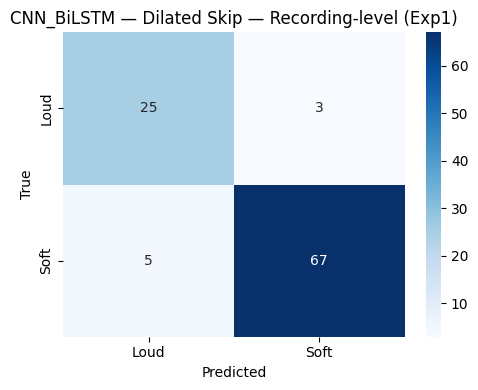

              precision    recall  f1-score   support

        Loud       0.69      0.79      0.74       569
        Soft       0.91      0.85      0.88      1393

    accuracy                           0.84      1962
   macro avg       0.80      0.82      0.81      1962
weighted avg       0.84      0.84      0.84      1962



In [ ]:
train_loader, val_loader, test_loader = make_loaders(batch_size=64)

model_1 = CNN_BiLSTM_DilatedSkip(input_size=INPUT_SIZE, cnn_channels=64, lstm_hidden=192,
                       lstm_layers=2, fc_hidden=192, num_classes=2, dropout=0.3).to(device)
history_1, best_val_1 = train_model2(model_1, train_loader, val_loader,
                                     epochs=80, lr=5e-4, patience=15,
                                     label='Exp 1 — Dilated Skip Baseline')
cycle_f1_1, rec_f1_1, preds_1, labels_1, probs_1, rec_preds_1, rec_trues_1 = evaluate_model(
    model_1, test_loader, label='Exp 1 — Dilated Skip Baseline')
plot_training(history_1, label='Exp1 Dilated Skip Baseline')
plot_confusion(preds_1,     labels_1,    label='Exp1', level='Cycle')
plot_confusion(rec_preds_1, rec_trues_1, label='Exp1', level='Recording')
print(classification_report(labels_1, preds_1, target_names=class_names))
results_table.append({'Experiment': '1 Dilated Skip Baseline', 'cnn_ch': 64, 'lstm_h': 192,
                       'dropout': 0.3, 'lr': 5e-4, 'batch': 64,
                       'Val F1': round(best_val_1, 4),
                       'Cycle F1': round(cycle_f1_1, 4), 'Rec F1': round(rec_f1_1, 4)})


### Experiment 2: Higher Dropout

`dropout=0.4` hecking p-0.3 vs 0.4 does higher dropout help?



Exp 2 — Dropout 0.4
  Params: 1,498,306
  Epoch  Train Loss  Train F1  Val Loss   Val F1
      1      0.4557    0.7616    0.5461   0.7374
      2      0.3836    0.8284    0.4935   0.7894
      3      0.3512    0.8564    0.5776   0.7987
      4      0.3362    0.8689    0.5070   0.7864
      5      0.3303    0.8659    0.5001   0.7837
      6      0.2947    0.8955    0.4672   0.8487
      7      0.2823    0.9008    0.5837   0.8145
      8      0.2705    0.9077    0.6944   0.7963
      9      0.2620    0.9130    0.4969   0.8444
     10      0.2406    0.9289    0.6347   0.8198
     11      0.2346    0.9317    0.5422   0.8530
     12      0.2212    0.9405    0.5674   0.8234
     13      0.2181    0.9415    0.5605   0.8370
     14      0.2080    0.9507    0.5746   0.8330
     15      0.2018    0.9523    0.5839   0.8422
     16      0.1987    0.9548    0.5671   0.8451
     17      0.1912    0.9573    0.5722   0.8495
     18      0.1934    0.9563    0.5732   0.8504
     19      0.1844    0.962

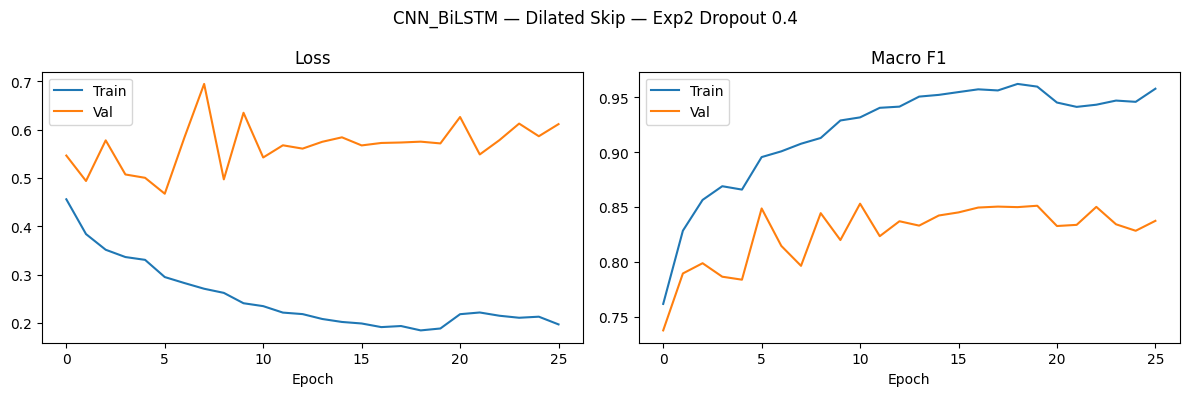

Saved: curves_exp2_dropout_0.4.png


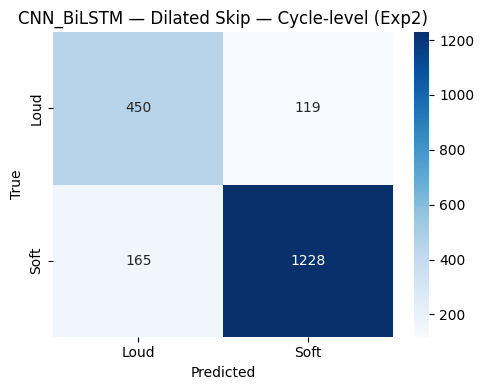

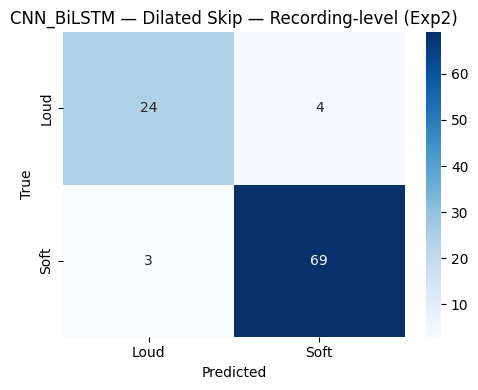

              precision    recall  f1-score   support

        Loud       0.73      0.79      0.76       569
        Soft       0.91      0.88      0.90      1393

    accuracy                           0.86      1962
   macro avg       0.82      0.84      0.83      1962
weighted avg       0.86      0.86      0.86      1962



In [ ]:
train_loader, val_loader, test_loader = make_loaders(batch_size=64)

model_2 = CNN_BiLSTM_DilatedSkip(input_size=INPUT_SIZE, cnn_channels=64, lstm_hidden=192,
                       lstm_layers=2, fc_hidden=192, num_classes=2, dropout=0.4).to(device)
history_2, best_val_2 = train_model2(model_2, train_loader, val_loader,
                                     epochs=80, lr=5e-4, patience=15,
                                     label='Exp 2 — Dropout 0.4')
cycle_f1_2, rec_f1_2, preds_2, labels_2, probs_2, rec_preds_2, rec_trues_2 = evaluate_model(
    model_2, test_loader, label='Exp 2 — Dropout 0.4')
plot_training(history_2, label='Exp2 Dropout 0.4')
plot_confusion(preds_2,     labels_2,    label='Exp2', level='Cycle')
plot_confusion(rec_preds_2, rec_trues_2, label='Exp2', level='Recording')
print(classification_report(labels_2, preds_2, target_names=class_names))
results_table.append({'Experiment': '2 Dropout 0.4', 'cnn_ch': 64, 'lstm_h': 192,
                       'dropout': 0.4, 'lr': 5e-4, 'batch': 64,
                       'Val F1': round(best_val_2, 4),
                       'Cycle F1': round(cycle_f1_2, 4), 'Rec F1': round(rec_f1_2, 4)})


### Experiment 3: Lower Learning Rate

`lr=1e-4` — more conservative initial learning rate.


Exp 3 — LR 1e-4
  Params: 1,498,306
  Epoch  Train Loss  Train F1  Val Loss   Val F1
      1      0.5058    0.7025    0.6366   0.7129
      2      0.4038    0.8129    0.5104   0.8050
      3      0.3814    0.8274    0.5443   0.7897
      4      0.3688    0.8384    0.5123   0.8025
      5      0.3500    0.8495    0.4967   0.8112
      6      0.3425    0.8602    0.5036   0.8183
      7      0.3380    0.8612    0.4805   0.8258
      8      0.3274    0.8716    0.4915   0.8244
      9      0.3229    0.8681    0.5325   0.8091
     10      0.3064    0.8819    0.5448   0.8019
     11      0.3006    0.8883    0.5478   0.8249
     12      0.3012    0.8848    0.5502   0.8145
     13      0.2976    0.8884    0.5140   0.8256
     14      0.2880    0.8924    0.5311   0.8244
     15      0.2826    0.8968    0.5448   0.8238
     16      0.2953    0.8898    0.5434   0.8222
     17      0.2896    0.8945    0.5358   0.8225
     18      0.2856    0.8941    0.5361   0.8241
     19      0.2854    0.8936   

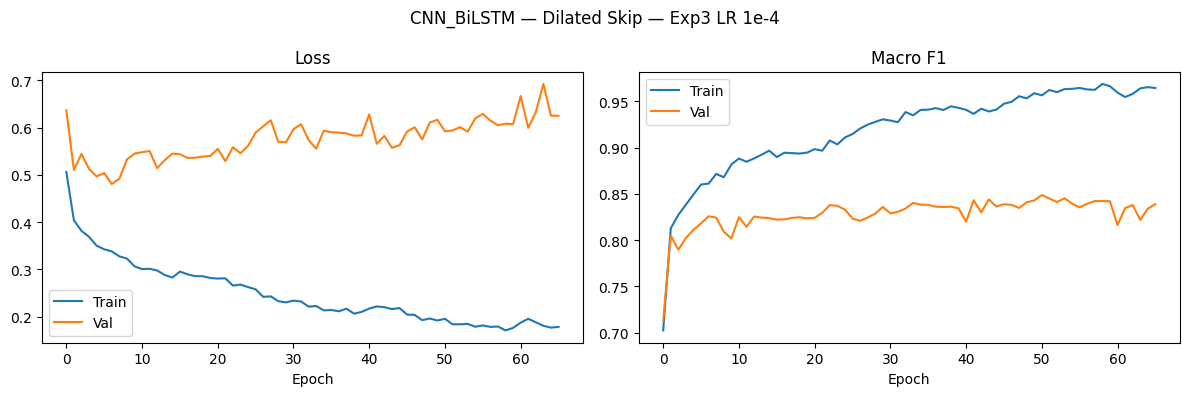

Saved: curves_exp3_lr_1e-4.png


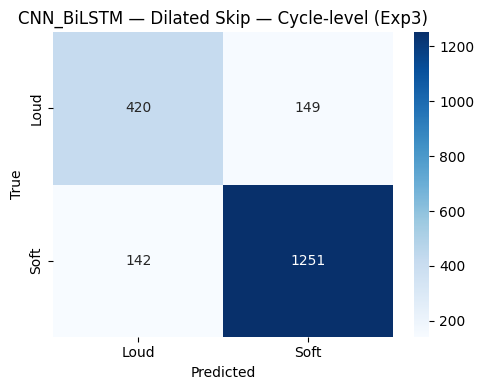

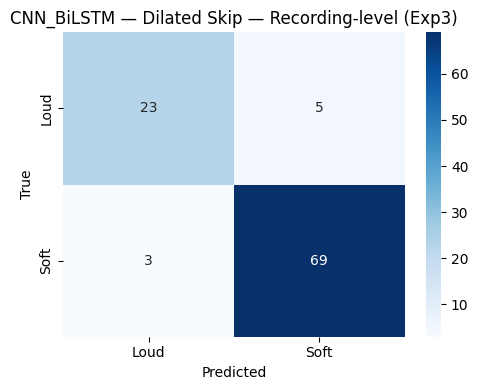

              precision    recall  f1-score   support

        Loud       0.75      0.74      0.74       569
        Soft       0.89      0.90      0.90      1393

    accuracy                           0.85      1962
   macro avg       0.82      0.82      0.82      1962
weighted avg       0.85      0.85      0.85      1962



In [ ]:
train_loader, val_loader, test_loader = make_loaders(batch_size=64)

model_3 = CNN_BiLSTM_DilatedSkip(input_size=INPUT_SIZE, cnn_channels=64, lstm_hidden=192,
                       lstm_layers=2, fc_hidden=192, num_classes=2, dropout=0.3).to(device)
history_3, best_val_3 = train_model2(model_3, train_loader, val_loader,
                                     epochs=80, lr=1e-4, patience=15,
                                     label='Exp 3 — LR 1e-4')
cycle_f1_3, rec_f1_3, preds_3, labels_3, probs_3, rec_preds_3, rec_trues_3 = evaluate_model(
    model_3, test_loader, label='Exp 3 — LR 1e-4')
plot_training(history_3, label='Exp3 LR 1e-4')
plot_confusion(preds_3,     labels_3,    label='Exp3', level='Cycle')
plot_confusion(rec_preds_3, rec_trues_3, label='Exp3', level='Recording')
print(classification_report(labels_3, preds_3, target_names=class_names))
results_table.append({'Experiment': '3 LR 1e-4', 'cnn_ch': 64, 'lstm_h': 192,
                       'dropout': 0.3, 'lr': 1e-4, 'batch': 64,
                       'Val F1': round(best_val_3, 4),
                       'Cycle F1': round(cycle_f1_3, 4), 'Rec F1': round(rec_f1_3, 4)})


### Experiment 4: Three LSTM Layers instead of 2

`lstm_layers=3`gives a deeper recurrent stack + adds skip connections guard against vanishing gradients.



Exp 4 — 3 LSTM Layers
  Params: 2,386,882
  Epoch  Train Loss  Train F1  Val Loss   Val F1
      1      0.4462    0.7728    0.4568   0.8296
      2      0.3581    0.8474    0.5149   0.7915
      3      0.3421    0.8634    0.5092   0.8087
      4      0.3155    0.8789    0.4785   0.8260
      5      0.2885    0.9009    0.5298   0.8244
      6      0.2732    0.9069    0.4948   0.8386
      7      0.2603    0.9144    0.5640   0.8438
      8      0.2430    0.9280    0.5606   0.8372
      9      0.2327    0.9320    0.5035   0.8434
     10      0.2204    0.9387    0.5773   0.8434
     11      0.2224    0.9373    0.5787   0.8182
     12      0.2016    0.9510    0.5770   0.8364
     13      0.1970    0.9535    0.6070   0.8378
     14      0.1953    0.9561    0.5651   0.8360
     15      0.1906    0.9578    0.5527   0.8495
     16      0.1847    0.9610    0.5622   0.8426
     17      0.1738    0.9678    0.5750   0.8427
     18      0.1766    0.9666    0.5709   0.8469
     19      0.1705    0.9

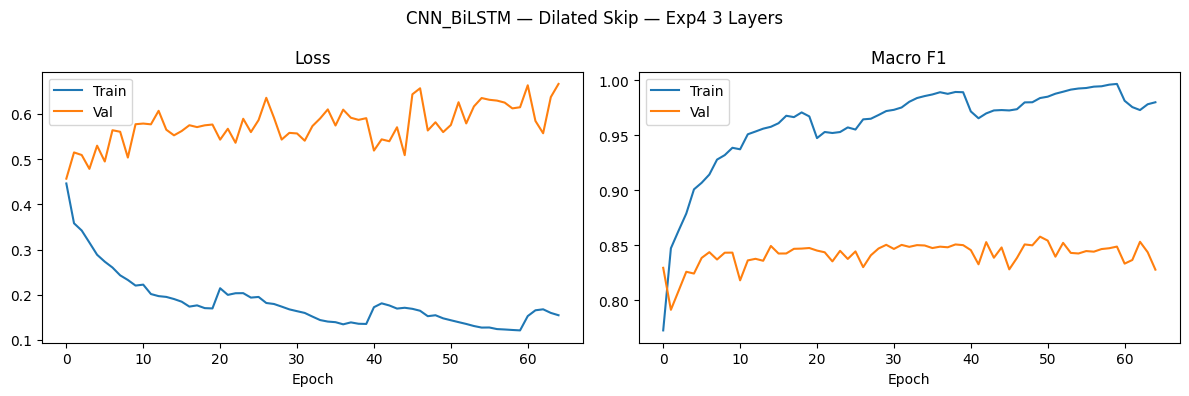

Saved: curves_exp4_3_layers.png


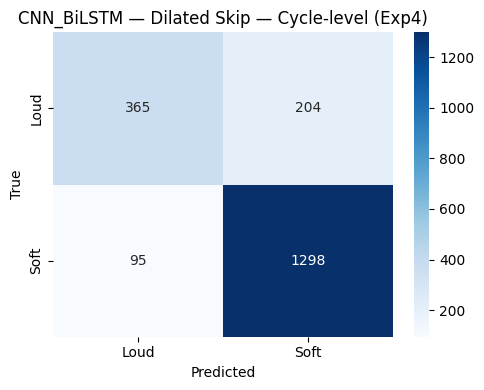

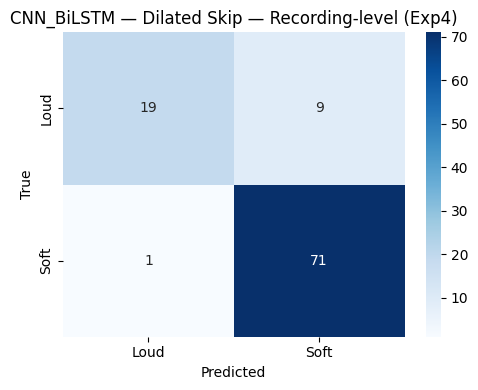

              precision    recall  f1-score   support

        Loud       0.79      0.64      0.71       569
        Soft       0.86      0.93      0.90      1393

    accuracy                           0.85      1962
   macro avg       0.83      0.79      0.80      1962
weighted avg       0.84      0.85      0.84      1962



In [ ]:
train_loader, val_loader, test_loader = make_loaders(batch_size=64)

model_4 = CNN_BiLSTM_DilatedSkip(input_size=INPUT_SIZE, cnn_channels=64, lstm_hidden=192,
                       lstm_layers=3, fc_hidden=192, num_classes=2, dropout=0.3).to(device)
history_4, best_val_4 = train_model2(model_4, train_loader, val_loader,
                                     epochs=80, lr=5e-4, patience=15,
                                     label='Exp 4 — 3 LSTM Layers')
cycle_f1_4, rec_f1_4, preds_4, labels_4, probs_4, rec_preds_4, rec_trues_4 = evaluate_model(
    model_4, test_loader, label='Exp 4 — 3 LSTM Layers')
plot_training(history_4, label='Exp4 3 Layers')
plot_confusion(preds_4,     labels_4,    label='Exp4', level='Cycle')
plot_confusion(rec_preds_4, rec_trues_4, label='Exp4', level='Recording')
print(classification_report(labels_4, preds_4, target_names=class_names))
results_table.append({'Experiment': '4 3-LSTM-layers', 'cnn_ch': 64, 'lstm_h': 192,
                       'dropout': 0.3, 'lr': 5e-4, 'batch': 64,
                       'Val F1': round(best_val_4, 4),
                       'Cycle F1': round(cycle_f1_4, 4), 'Rec F1': round(rec_f1_4, 4)})


### Experiment 5: Smaller Batches

`batch_size=32`vs 64 gives more gradient updates per epoch.



Exp 5 — Batch 32
  Params: 1,498,306
  Epoch  Train Loss  Train F1  Val Loss   Val F1
      1      0.4233    0.7906    0.5876   0.7842
      2      0.3493    0.8580    0.6909   0.7792
      3      0.3161    0.8821    0.8466   0.7665
      4      0.3073    0.8864    0.5654   0.8167
      5      0.2798    0.9020    0.6158   0.8329
      6      0.2637    0.9136    0.6410   0.8143
      7      0.2478    0.9253    0.5115   0.8605
      8      0.2307    0.9330    0.6788   0.8457
      9      0.2249    0.9379    0.5636   0.8436
     10      0.2138    0.9446    0.6214   0.8465
     11      0.2089    0.9480    0.6224   0.8489
     12      0.2012    0.9538    0.5672   0.8530
     13      0.1886    0.9579    0.5638   0.8611
     14      0.1808    0.9664    0.6122   0.8564
     15      0.1699    0.9707    0.6185   0.8513
     16      0.1717    0.9711    0.6161   0.8503
     17      0.1735    0.9704    0.6144   0.8469
     18      0.1702    0.9712    0.5906   0.8524
     19      0.1674    0.9733  

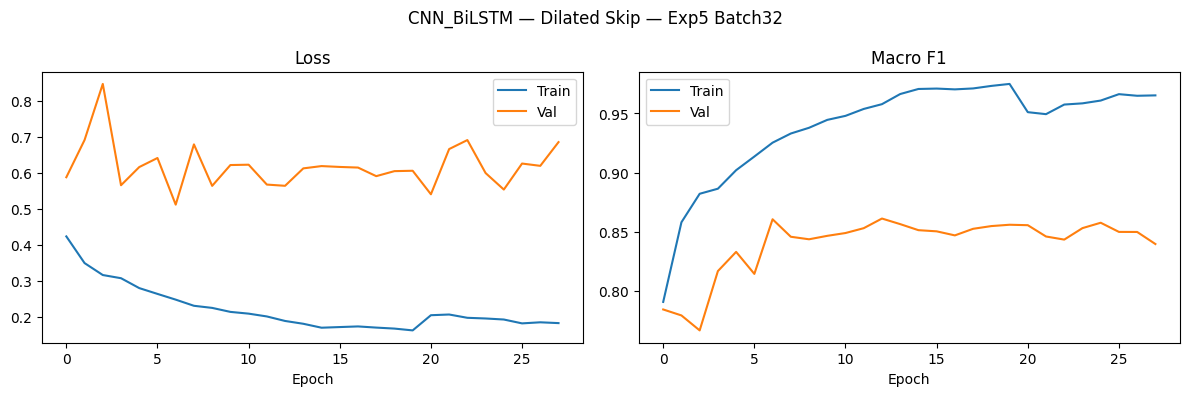

Saved: curves_exp5_batch32.png


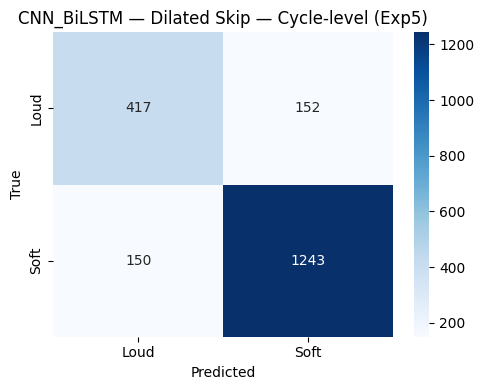

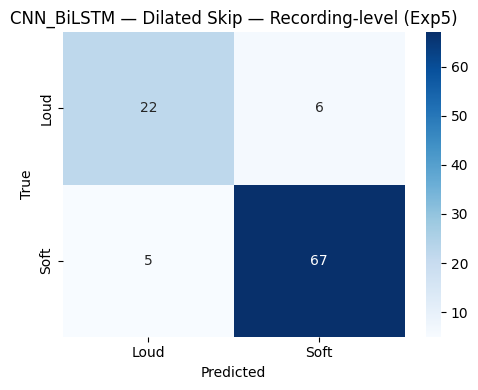

              precision    recall  f1-score   support

        Loud       0.74      0.73      0.73       569
        Soft       0.89      0.89      0.89      1393

    accuracy                           0.85      1962
   macro avg       0.81      0.81      0.81      1962
weighted avg       0.85      0.85      0.85      1962



In [ ]:
train_loader, val_loader, test_loader = make_loaders(batch_size=32)

model_5 = CNN_BiLSTM_DilatedSkip(input_size=INPUT_SIZE, cnn_channels=64, lstm_hidden=192,
                       lstm_layers=2, fc_hidden=192, num_classes=2, dropout=0.3).to(device)
history_5, best_val_5 = train_model2(model_5, train_loader, val_loader,
                                     epochs=80, lr=5e-4, patience=15,
                                     label='Exp 5 — Batch 32')
cycle_f1_5, rec_f1_5, preds_5, labels_5, probs_5, rec_preds_5, rec_trues_5 = evaluate_model(
    model_5, test_loader, label='Exp 5 — Batch 32')
plot_training(history_5, label='Exp5 Batch32')
plot_confusion(preds_5,     labels_5,    label='Exp5', level='Cycle')
plot_confusion(rec_preds_5, rec_trues_5, label='Exp5', level='Recording')
print(classification_report(labels_5, preds_5, target_names=class_names))
results_table.append({'Experiment': '5 Batch 32', 'cnn_ch': 64, 'lstm_h': 192,
                       'dropout': 0.3, 'lr': 5e-4, 'batch': 32,
                       'Val F1': round(best_val_5, 4),
                       'Cycle F1': round(cycle_f1_5, 4), 'Rec F1': round(rec_f1_5, 4)})


### Experiment 6: a Larger CNN and LSTM

`cnn_channels=128, lstm_hidden=256` does more capacity help?



Exp 6 — CNN-128 LSTM-256
  Params: 2,776,578
  Epoch  Train Loss  Train F1  Val Loss   Val F1
      1      0.4590    0.7625    0.5677   0.7689
      2      0.3688    0.8398    0.5168   0.7947
      3      0.3327    0.8643    0.4748   0.8242
      4      0.3153    0.8744    0.5046   0.8277
      5      0.3177    0.8797    0.5270   0.8346
      6      0.2867    0.8980    0.6181   0.7834
      7      0.2645    0.9129    0.5433   0.8416
      8      0.2344    0.9320    0.5449   0.8371
      9      0.2320    0.9304    0.5379   0.8304
     10      0.2205    0.9406    0.6047   0.8267
     11      0.2126    0.9439    0.6443   0.8177
     12      0.2061    0.9491    0.5997   0.8246
     13      0.1958    0.9564    0.5411   0.8494
     14      0.1844    0.9620    0.6061   0.8460
     15      0.1803    0.9654    0.5848   0.8496
     16      0.1771    0.9670    0.5971   0.8500
     17      0.1740    0.9694    0.5867   0.8538
     18      0.1712    0.9691    0.6066   0.8476
     19      0.1740    

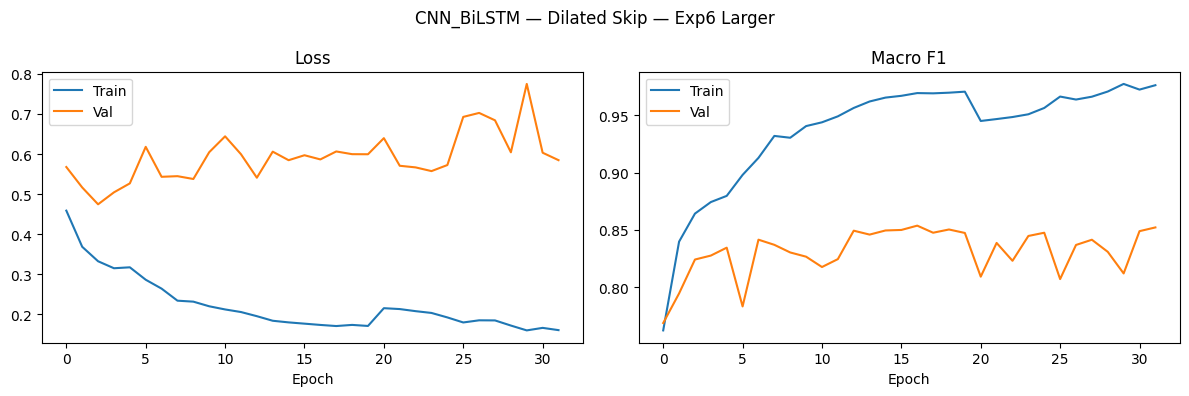

Saved: curves_exp6_larger.png


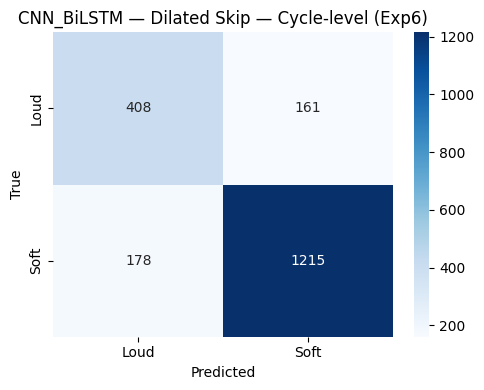

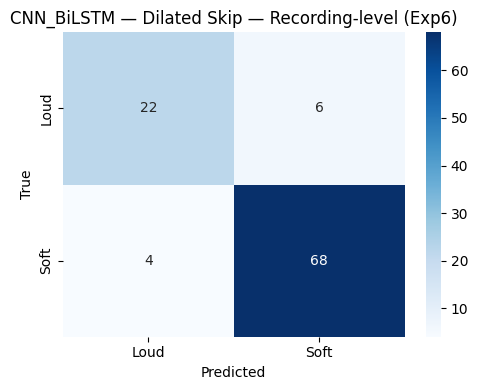

              precision    recall  f1-score   support

        Loud       0.70      0.72      0.71       569
        Soft       0.88      0.87      0.88      1393

    accuracy                           0.83      1962
   macro avg       0.79      0.79      0.79      1962
weighted avg       0.83      0.83      0.83      1962



In [ ]:
train_loader, val_loader, test_loader = make_loaders(batch_size=64)

model_6 = CNN_BiLSTM_DilatedSkip(input_size=INPUT_SIZE, cnn_channels=128, lstm_hidden=256,
                       lstm_layers=2, fc_hidden=256, num_classes=2, dropout=0.4).to(device)
history_6, best_val_6 = train_model2(model_6, train_loader, val_loader,
                                     epochs=80, lr=5e-4, patience=15,
                                     label='Exp 6 — CNN-128 LSTM-256')
cycle_f1_6, rec_f1_6, preds_6, labels_6, probs_6, rec_preds_6, rec_trues_6 = evaluate_model(
    model_6, test_loader, label='Exp 6 — CNN-128 LSTM-256')
plot_training(history_6, label='Exp6 Larger')
plot_confusion(preds_6,     labels_6,    label='Exp6', level='Cycle')
plot_confusion(rec_preds_6, rec_trues_6, label='Exp6', level='Recording')
print(classification_report(labels_6, preds_6, target_names=class_names))
results_table.append({'Experiment': '6 CNN128 LSTM256', 'cnn_ch': 128, 'lstm_h': 256,
                       'dropout': 0.4, 'lr': 5e-4, 'batch': 64,
                       'Val F1': round(best_val_6, 4),
                       'Cycle F1': round(cycle_f1_6, 4), 'Rec F1': round(rec_f1_6, 4)})


## Experiment Comparison


CNN_BiLSTM — Dilated Skip Experiment Results
             Experiment  cnn_ch  lstm_h  dropout     lr  batch  Val F1  Cycle F1  Rec F1
1 Dilated Skip Baseline      64     192      0.3 0.0005     64  0.8487    0.8078  0.9029
          2 Dropout 0.4      64     192      0.4 0.0005     64  0.8530    0.8282  0.9122
              3 LR 1e-4      64     192      0.3 0.0001     64  0.8489    0.8193  0.8985
        4 3-LSTM-layers      64     192      0.3 0.0005     64  0.8579    0.8031  0.8629
             5 Batch 32      64     192      0.3 0.0005     32  0.8611    0.8129  0.8621
       6 CNN128 LSTM256     128     256      0.4 0.0005     64  0.8538    0.7920  0.8732

Best model: 2 Dropout 0.4
  Cycle F1:     0.8282
  Recording F1: 0.9122


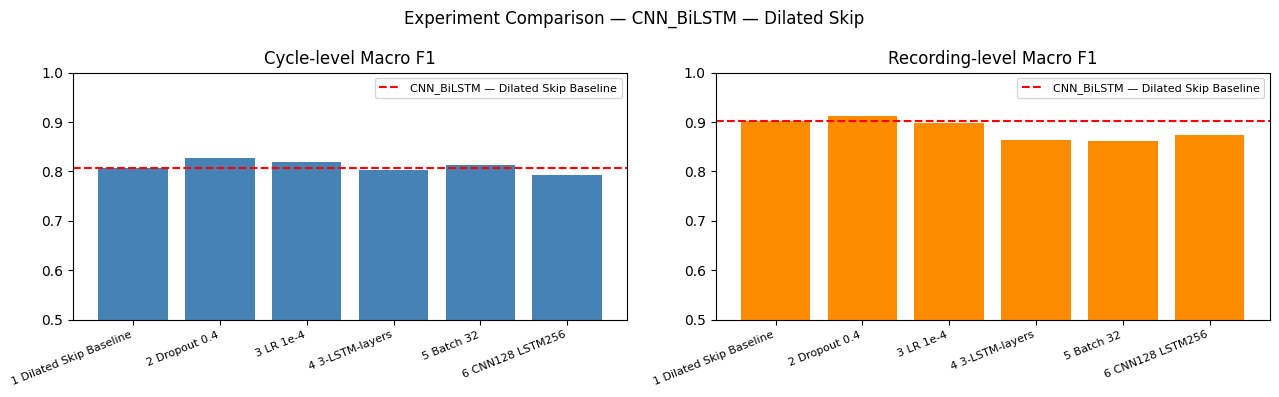

In [ ]:
results_df = pd.DataFrame(results_table)
print('CNN_BiLSTM — Dilated Skip Experiment Results')
print(results_df.to_string(index=False))

best_idx = results_df['Rec F1'].idxmax()
print(f'\nBest model: {results_df.loc[best_idx, "Experiment"]}')
print(f'  Cycle F1:     {results_df.loc[best_idx, "Cycle F1"]}')
print(f'  Recording F1: {results_df.loc[best_idx, "Rec F1"]}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
x = range(len(results_df))
ax1.bar(x, results_df['Cycle F1'], color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Experiment'], rotation=22, ha='right', fontsize=8)
ax1.set_title('Cycle-level Macro F1'); ax1.set_ylim(0.5, 1.0)
ax1.axhline(results_df['Cycle F1'].iloc[0], color='red', ls='--', label='CNN_BiLSTM — Dilated Skip Baseline')
ax1.legend(fontsize=8)
ax2.bar(x, results_df['Rec F1'], color='darkorange')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Experiment'], rotation=22, ha='right', fontsize=8)
ax2.set_title('Recording-level Macro F1'); ax2.set_ylim(0.5, 1.0)
ax2.axhline(results_df['Rec F1'].iloc[0], color='red', ls='--', label='CNN_BiLSTM — Dilated Skip Baseline')
ax2.legend(fontsize=8)
plt.suptitle('Experiment Comparison — CNN_BiLSTM — Dilated Skip')
plt.tight_layout()
plt.savefig('experiment_comparison_dilated_skip.png', dpi=150); plt.show()


## Final Model — Full Diagnostics

Update the cell below to point at the experiment with the highest recording-level F1.


In [ ]:
# Update this to whichever experiment had the highest recording-level F1
model_final  = model_1
history_f    = history_1
cycle_f1_f   = cycle_f1_1
rec_f1_f     = rec_f1_1
preds_f      = preds_1
labels_f     = labels_1
probs_f      = probs_1
rec_preds_f  = rec_preds_1
rec_trues_f  = rec_trues_1

print(f'Final — Cycle F1: {cycle_f1_f:.4f}  |  Recording F1: {rec_f1_f:.4f}')


Final — Cycle F1: 0.8078  |  Recording F1: 0.9029


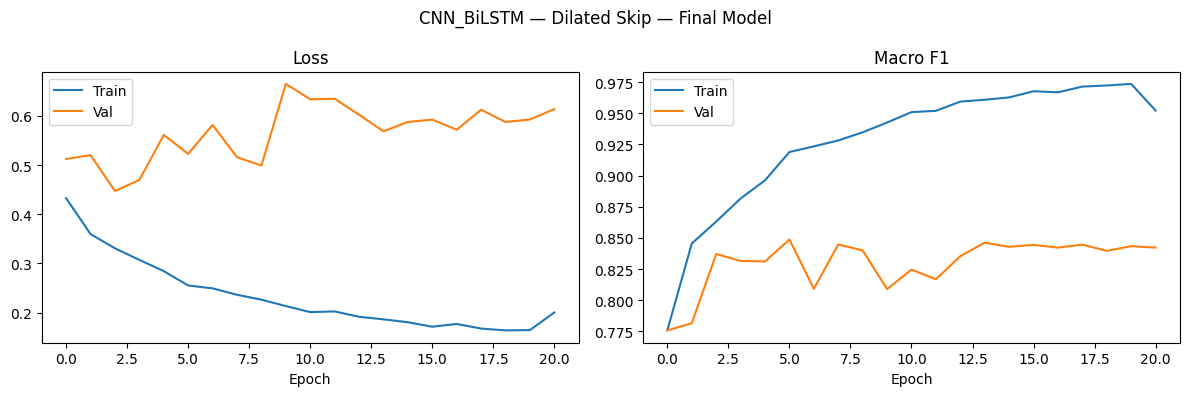

Saved: curves_final_model.png

Cycle-level Classification Report
              precision    recall  f1-score   support

        Loud       0.69      0.79      0.74       569
        Soft       0.91      0.85      0.88      1393

    accuracy                           0.84      1962
   macro avg       0.80      0.82      0.81      1962
weighted avg       0.84      0.84      0.84      1962



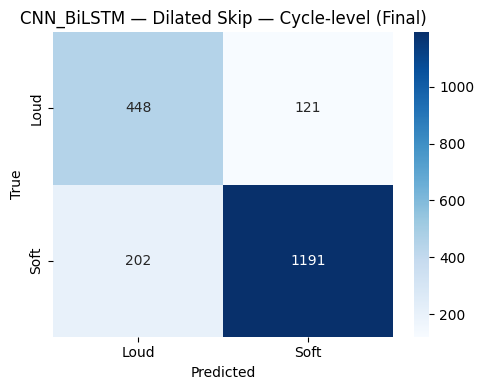


Recording-level Classification Report
              precision    recall  f1-score   support

        Loud       0.83      0.89      0.86        28
        Soft       0.96      0.93      0.94        72

    accuracy                           0.92       100
   macro avg       0.90      0.91      0.90       100
weighted avg       0.92      0.92      0.92       100



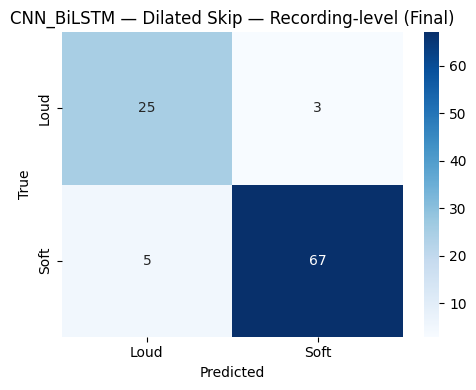

In [ ]:
plot_training(history_f, label='Final Model')
print('\nCycle-level Classification Report')
print(classification_report(labels_f, preds_f, target_names=class_names))
plot_confusion(preds_f,     labels_f,    label='Final', level='Cycle')
print('\nRecording-level Classification Report')
print(classification_report(rec_trues_f, rec_preds_f, target_names=class_names))
plot_confusion(rec_preds_f, rec_trues_f, label='Final', level='Recording')


### Bootstrap 95% Confidence Intervals

1000 resamples on cycle-level and recording-level F1.


Bootstrap 95% CI (n=1000)
  Cycle-level     F1: 0.8078  95% CI [0.7881, 0.8275]
  Recording-level F1: 0.9029  95% CI [0.8370, 0.9615]


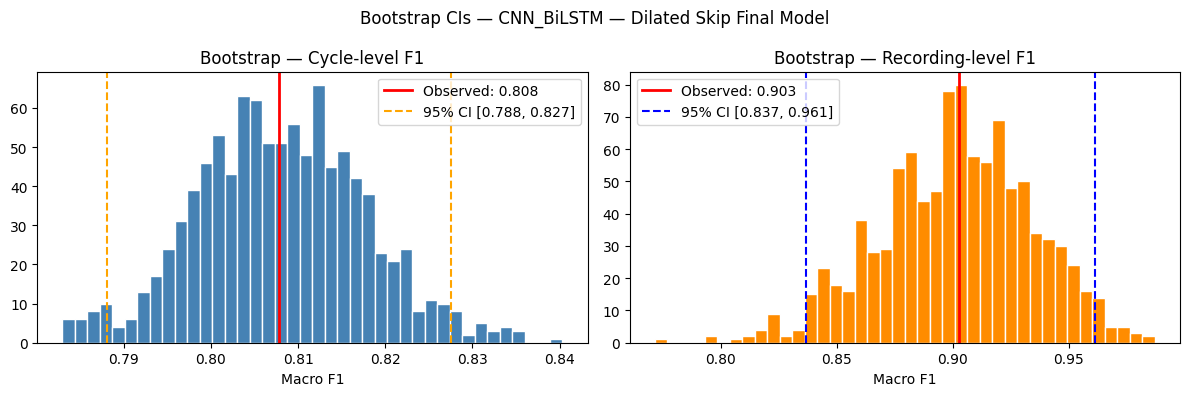

Saved: bootstrap_ci_dilated_skip.png


In [ ]:
from sklearn.utils import resample

N_BOOTSTRAP = 1000
np.random.seed(42)
cycle_f1s_boot, rec_f1s_boot = [], []

for _ in range(N_BOOTSTRAP):
    idx = resample(range(len(labels_f)))
    s_l = [labels_f[i] for i in idx]
    s_p = [preds_f[i]  for i in idx]
    if len(set(s_l)) > 1:
        cycle_f1s_boot.append(f1_score(s_l, s_p, average='macro', zero_division=0))

for _ in range(N_BOOTSTRAP):
    idx = resample(range(len(rec_trues_f)))
    s_l = [rec_trues_f[i] for i in idx]
    s_p = [rec_preds_f[i] for i in idx]
    if len(set(s_l)) > 1:
        rec_f1s_boot.append(f1_score(s_l, s_p, average='macro', zero_division=0))

c_lo, c_hi = np.percentile(cycle_f1s_boot, [2.5, 97.5])
r_lo, r_hi = np.percentile(rec_f1s_boot,   [2.5, 97.5])

print('Bootstrap 95% CI (n=1000)')
print(f'  Cycle-level     F1: {cycle_f1_f:.4f}  95% CI [{c_lo:.4f}, {c_hi:.4f}]')
print(f'  Recording-level F1: {rec_f1_f:.4f}  95% CI [{r_lo:.4f}, {r_hi:.4f}]')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(cycle_f1s_boot, bins=40, color='steelblue', edgecolor='white')
ax1.axvline(cycle_f1_f, color='red', lw=2, label=f'Observed: {cycle_f1_f:.3f}')
ax1.axvline(c_lo, color='orange', ls='--', label=f'95% CI [{c_lo:.3f}, {c_hi:.3f}]')
ax1.axvline(c_hi, color='orange', ls='--')
ax1.set_title('Bootstrap — Cycle-level F1'); ax1.set_xlabel('Macro F1'); ax1.legend()
ax2.hist(rec_f1s_boot, bins=40, color='darkorange', edgecolor='white')
ax2.axvline(rec_f1_f, color='red', lw=2, label=f'Observed: {rec_f1_f:.3f}')
ax2.axvline(r_lo, color='blue', ls='--', label=f'95% CI [{r_lo:.3f}, {r_hi:.3f}]')
ax2.axvline(r_hi, color='blue', ls='--')
ax2.set_title('Bootstrap — Recording-level F1'); ax2.set_xlabel('Macro F1'); ax2.legend()
plt.suptitle('Bootstrap CIs — CNN_BiLSTM — Dilated Skip Final Model')
plt.tight_layout()
plt.savefig('bootstrap_ci_dilated_skip.png', dpi=150); plt.show()
print('Saved: bootstrap_ci_dilated_skip.png')
